


### 基于K-Means聚类与多模型时序预测的重庆上市车企财务智能预警研究
#### ——赛力斯外部协同经营模式对标长安自主研发模式

**核心研究问题**：代工协同模式（赛力斯）和自主研发模式（长安），谁的财务风险更高、更不稳定？

目录

<div style="border:1px solid #4c4c4c;border-radius:8px;padding:12px 16px;background:#f9f9f9;color:#333333;font-size:14px;">
<ul style="line-height:2.1;margin:0;padding-left:22px;">
  <li><a href="#sec-1">一、数据获取与预处理</a></li>
  <li><a href="#sec-2">二、财务指标探索（18 项指标 → 5 维风险特征）</a></li>
  <li><a href="#sec-3">三、财务分析（K-Means 聚类 / 异常检测 / 多模型时序预测 / 回测）</a></li>
  <li><a href="#sec-4">四、行业NEV销量与财务联动分析</a></li>
  <li><a href="#sec-5">五、综合评价（杜邦分析 / Z-score / 沃尔评分）</a></li>
  <li><a href="#sec-6">六、结论与对策建议</a></li>
</ul>
</div>


<a id="sec-1"></a>

##### 一、数据获取与预处理

1. 数据获取

（1）获取财务报表数据：2016年Q1-2025年Q4：`data/collect_financial_data.py`

（2）获取车企销售数据：2023年Q1-2026年Q4：销售量：`data/add_company_sales.py`；销售结构：`data/extract_sales_structure.py`

（3）2026Q1追加采集财务数据（赛力斯+长安）：`data/collect_2026q1_for_mape.py`

（4）追加中国汽车行业多维销量数据：2016Q1_2025Q4：`data\enrich_nev_data.py`；`data\nev_industry_analysis.py`

2. 数据预处理

（1）数据读取


In [ ]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams.update({
    'font.sans-serif': ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS'],
    'axes.unicode_minus': False,
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal'
})

data_dir = Path('data')
all_data = {
    file.stem.replace('_财务数据', ''): pd.read_excel(file)
    for file in data_dir.glob('*_财务数据.xlsx')
}
for company, df in all_data.items():
    print(f"{company}: {len(df)} 条记录")
list(all_data.values())[0].head()

000625_长安汽车: 69 条记录
002594_比亚迪: 64 条记录
600104_上汽集团: 69 条记录
600418_江淮汽车: 61 条记录
600733_北汽蓝谷: 61 条记录
601127_赛力斯: 63 条记录
601238_广汽集团: 69 条记录
601633_长城汽车: 65 条记录


,Unnamed: 0,2016年报,2016Q1,2016Q2,2016Q3,2017年报,2017Q1,2017Q2,2017Q3,2018年报,...,2023Q3,2024年报,2024Q1,2024Q2,2024Q3,2025年报,2025Q1,2025Q2,2025Q3,2026Q1
0,货币资金,24783000000.00,18717000000.00,21358000000.00,25103000000.00,22632000000.00,28328000000.00,27882000000.00,23992000000.00,9981000000.00,...,72192000000.00,64182000000.00,70068000000.00,70939000000.00,70005000000.00,54022000000.00,60129000000.00,52830000000.00,55241000000.00,39831000000.00
1,交易性金融资产,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,157000000.00,155000000.00,144000000.00,153000000.00,167000000.00,NaN,150000000.00,162000000.00,102400.00,80000000.00
2,应收账款,1499000000.00,1270000000.00,1480000000.00,1518000000.00,1807000000.00,2427000000.00,1900000000.00,1996000000.00,1409000000.00,...,2669000000.00,3398000000.00,3277000000.00,2989000000.00,4226000000.00,4197000000.00,5021000000.00,6628000000.00,7216000000.00,11735000000.00
3,应收票据及应收账款,30501000000.00,24141000000.00,21313000000.00,21622000000.00,30963000000.00,25880000000.00,23635000000.00,23361000000.00,21971000000.00,...,38047000000.00,48979000000.00,36982000000.00,36985000000.00,33443000000.00,37195000000.00,42850000000.00,32185000000.00,27734000000.00,40754000000.00
4,预付款项,1061000000.00,670000000.00,991000000.00,880000000.00,1102000000.00,1323000000.00,1274000000.00,1832000000.00,866000000.00,...,988000000.00,507000000.00,482000000.00,583000000.00,456000000.00,492000000.00,436000000.00,400000000.00,794000000.00,719000000.00


（2） 报表合并

In [2]:
def integrate_financial_data(company_code):
    file_path = f'data/{company_code}_财务数据.xlsx'
    df_balance = pd.read_excel(file_path, sheet_name='资产负债表', index_col=0)
    df_income  = pd.read_excel(file_path, sheet_name='利润表', index_col=0)
    df_cash    = pd.read_excel(file_path, sheet_name='现金流量表', index_col=0)
    df_balance = df_balance.T.add_suffix('_资产')
    df_income  = df_income.T.add_suffix('_利润')
    df_cash    = df_cash.T.add_suffix('_现金流')
    
    data = pd.concat([df_income, df_balance, df_cash], axis=1).fillna(0)
    print(f'完成: {len(data)} 期 × {len(data.columns)} 个指标')
    return data  

companies = [f.stem.replace('_财务数据','') for f in Path('data').glob('*_财务数据.xlsx')]
print('可用公司:', companies)
data = integrate_financial_data('601127_赛力斯')
data = data.dropna(axis=1, how='all')
data.info()
data.head()

可用公司: ['000625_长安汽车', '002594_比亚迪', '600104_上汽集团', '600418_江淮汽车', '600733_北汽蓝谷', '601127_赛力斯', '601238_广汽集团', '601633_长城汽车']
完成: 42 期 × 157 个指标
<class 'pandas.DataFrame'>
Index: 42 entries, 2016年报 to 2026Q1.1
Columns: 157 entries, 一、营业总收入_利润 to 间接法-现金及现金等价物净增加额_现金流
dtypes: float64(157)
memory usage: 51.8+ KB


,一、营业总收入_利润,营业收入_利润,税金及附加_利润,销售费用_利润,管理费用_利润,研发费用_利润,财务费用_利润,其中：利息费用_利润,其中：利息收入_利润,投资收益_利润,...,投资损失_现金流,递延所得税资产减少_现金流,递延所得税负债增加_现金流,存货的减少_现金流,经营性应收项目的减少_现金流,经营性应付项目的增加_现金流,间接法-经营活动产生的现金流量净额_现金流,现金的期末余额_现金流,减：现金的期初余额_现金流,间接法-现金及现金等价物净增加额_现金流
2016年报,16192433345.64,16192433345.64,507065517.42,1040867383.23,857649823.83,0.00,31223587.42,0.00,0.00,17085648.52,...,-17085600.00,-2747300.00,-2803400.00,-398000000.00,-3166000000.00,3396000000.00,1146000000.00,2354000000.00,783000000.00,1571000000.00
2016Q1,3192494361.94,3192494361.94,89758235.88,235452003.17,190455452.35,0.00,19150137.50,0.00,0.00,3113381.63,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2016Q2,6335555683.44,6335555683.44,167986672.51,449972564.03,362921849.04,0.00,39083090.27,0.00,0.00,4811555.19,...,-4811600.00,2414900.00,-1409500.00,-94636200.00,-94507300.00,232000000.00,614000000.00,1813000000.00,783000000.00,1030000000.00
2016Q3,10201440748.18,10201440748.18,283091859.47,701568465.96,548065997.74,0.00,49897945.70,0.00,0.00,13988970.02,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017年报,21933763911.67,21933763911.67,699669865.17,1282388655.04,913846191.09,467812314.43,30211619.41,137861810.57,117984910.51,14875439.06,...,-14875400.00,-7041700.00,-2344900.00,-242000000.00,-931000000.00,134000000.00,997000000.00,4366000000.00,2354000000.00,2012000000.00


In [3]:
from tqdm import tqdm
files = list(Path('data').glob('*_财务数据.xlsx'))
for fp in tqdm(files, desc='处理'):
    code = fp.stem.replace('_财务数据', '')
    data = integrate_financial_data(code)
    with pd.ExcelWriter(fp, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        data.to_excel(writer, sheet_name='合并报表', index=True)
print('done!')

处理:   0%|          | 0/8 [00:00<?, ?it/s]

完成: 41 期 × 163 个指标


处理:  12%|█▎        | 1/8 [00:00<00:05,  1.35it/s]

完成: 40 期 × 159 个指标


处理:  25%|██▌       | 2/8 [00:01<00:04,  1.35it/s]

...

完成: 40 期 × 169 个指标


处理:  88%|████████▊ | 7/8 [00:04<00:00,  1.41it/s]

完成: 40 期 × 160 个指标


处理: 100%|██████████| 8/8 [00:05<00:00,  1.41it/s]

done!


（4） 静态财务指标

In [4]:
def financial_ratio(name, data):
    # 18个指标
    col = {
        '营收': '营业收入_利润', '营成': '营业成本_利润', '营利': '营业利润_利润',
        '净利': '净利润_利润', '归母净利': '归属于母公司所有者的净利润_利润',
        '利息': '其中：利息费用_利润', '存货': '存货_资产', '资产': '资产合计_资产',
        '负债': '负债合计_资产', '货币资金': '货币资金_资产', '应收': '应收账款_资产',
        '流资': '流动资产合计_资产', '流负': '流动负债合计_资产',
        '预付': '预付款项_资产', '权益': '归属于母公司所有者权益合计_资产',
    }

    # 有息负债列检测
    ib_keys = ['短期借款_资产','长期借款_资产','应付债券_资产','一年内到期的非流动负债_资产']
    ib_cols = {k: data[k] for k in ib_keys if k in data.columns}
    has_ib = len(ib_cols) > 0

    # 经营现金流列检测
    ocf_col = None
    for c in data.columns:
        if '经营' in c and '现金流' in c and '净额' in c:
            ocf_col = c; break

    # 新列一次性构建
    new_cols = {}
    new_cols['息税前利润'] = data[col['营利']] + data[col['利息']]
    new_cols['毛利率'] = 1 - data[col['营成']] / data[col['营收']]
    new_cols['营业利润率'] = data[col['营利']] / data[col['营收']]
    new_cols['净利润率'] = data[col['净利']] / data[col['营收']]
    new_cols['净资产收益率'] = 2 * data[col['归母净利']] / (
        data[col['权益']] + data[col['权益']].shift(1))
    new_cols['存货周转率'] = 2 * data[col['营成']] / (
        data[col['存货']] + data[col['存货']].shift(1))
    new_cols['总资产周转率'] = 2 * data[col['营收']] / (
        data[col['资产']] + data[col['资产']].shift(1))
    new_cols['应收账款周转率'] = 2 * data[col['营收']] / (
        data[col['应收']] + data[col['应收']].shift(1))
    new_cols['流动比率'] = data[col['流资']] / data[col['流负']]
    new_cols['速动比率'] = (data[col['流资']] - data[col['存货']] - data[col['预付']]) / data[col['流负']]
    new_cols['利息保障倍数'] = new_cols['息税前利润'] / data[col['利息']]
    new_cols['资产负债率'] = data[col['负债']] / data[col['资产']]
    new_cols['货币资金占比'] = data[col['货币资金']] / data[col['资产']]
    new_cols['营业收入增长率'] = data[col['营收']] / data[col['营收']].shift(1) - 1
    new_cols['营业利润增长率'] = data[col['营利']] / data[col['营利']].shift(1) - 1
    new_cols['净利润增长率'] = data[col['净利']] / data[col['净利']].shift(1) - 1

    if has_ib:
        total_ib = sum(ib_cols.values())
        new_cols['有息负债率'] = total_ib / data[col['资产']]
    else:
        new_cols['有息负债率'] = np.nan

    if ocf_col:
        new_cols['经营现金流/营收'] = data[ocf_col] / data[col['营收']]
    else:
        new_cols['经营现金流/营收'] = np.nan

    new_cols['权益乘数'] = data[col['资产']] / data[col['权益']]

    df_new = pd.concat(new_cols, axis=1)

    cols = ['毛利率','营业利润率','净利润率','净资产收益率',
            '存货周转率','总资产周转率','应收账款周转率',
            '流动比率','速动比率','利息保障倍数','资产负债率','货币资金占比',
            '营业收入增长率','营业利润增长率','净利润增长率',
            '有息负债率','经营现金流/营收','权益乘数']
    df = df_new[cols].iloc[1:].copy()
    df.index = data.index[1:]
    df[np.isinf(df)] = 0

    with pd.ExcelWriter(f'data/{name}_财务数据.xlsx',
                        engine='openpyxl', mode='a',
                        if_sheet_exists='replace') as writer:
        df.to_excel(writer, sheet_name='财务指标表', index=True)

    print(f' {name}: 财务指标表已保存 ({len(df)}期x{len(df.columns)}指标)')
    return df
data = integrate_financial_data('601127_赛力斯')
df_ratio = financial_ratio(name='601127_赛力斯', data=data)
df_ratio.head()

完成: 42 期 × 157 个指标
 601127_赛力斯: 财务指标表已保存 (41期x18指标)


,毛利率,营业利润率,净利润率,净资产收益率,存货周转率,总资产周转率,应收账款周转率,流动比率,速动比率,利息保障倍数,资产负债率,货币资金占比,营业收入增长率,营业利润增长率,净利润增长率,有息负债率,经营现金流/营收,权益乘数
2016Q1,0.04,0.04,0.04,0.04,5.60,0.19,16.25,NaN,NaN,0.00,0.76,0.00,-0.80,-0.80,-0.79,0.00,0.06,5.16
2016Q2,0.04,0.04,0.03,0.06,15.03,0.43,30.24,0.91,0.81,0.00,0.73,0.20,0.98,0.62,0.61,0.14,0.10,4.29
2016Q3,0.03,0.03,0.03,0.08,11.78,0.63,24.70,0.90,0.79,0.00,0.75,0.19,0.61,0.47,0.47,0.13,0.08,4.73
2017年报,0.06,0.06,0.05,0.17,18.77,1.07,32.16,1.00,0.88,11.05,0.75,0.25,1.15,3.08,2.46,0.21,0.05,5.02
2017Q1,0.06,0.06,0.05,0.05,3.69,0.26,8.83,0.89,0.77,0.00,0.77,0.23,-0.73,-0.74,-0.74,0.13,0.09,5.26


In [5]:
all_ratios = {}
for fp in Path('data').glob('*_财务数据.xlsx'):
    code = fp.stem.replace('_财务数据', '')
    print(f'处理: {code} ... ', end='')
    
    xl = pd.ExcelFile(fp)
    if '合并报表' in xl.sheet_names:
        data = pd.read_excel(xl, '合并报表', index_col=0)
    else:
        data = integrate_financial_data(code)

    df_ratio = financial_ratio(name=code, data=data)
    all_ratios[code] = df_ratio
    print(f'OK ({len(df_ratio)}期)')
print(f'\n 完成: {len(all_ratios)} 家公司')

处理: 000625_长安汽车 ...  000625_长安汽车: 财务指标表已保存 (40期x18指标)
OK (40期)
处理: 002594_比亚迪 ...  002594_比亚迪: 财务指标表已保存 (39期x18指标)
OK (39期)
处理: 600104_上汽集团 ...  600104_上汽集团: 财务指标表已保存 (39期x18指标)
OK (39期)
处理: 600418_江淮汽车 ...  600418_江淮汽车: 财务指标表已保存 (39期x18指标)
OK (39期)
处理: 600733_北汽蓝谷 ...  600733_北汽蓝谷: 财务指标表已保存 (39期x18指标)
OK (39期)
处理: 601127_赛力斯 ...  601127_赛力斯: 财务指标表已保存 (41期x18指标)
OK (41期)
处理: 601238_广汽集团 ...  601238_广汽集团: 财务指标表已保存 (39期x18指标)
OK (39期)
处理: 601633_长城汽车 ...  601633_长城汽车: 财务指标表已保存 (39期x18指标)
OK (39期)

 完成: 8 家公司


<a id="sec-2"></a>

##### 二、财务指标探索

1.八家车企核心指标对比（热力图）

findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


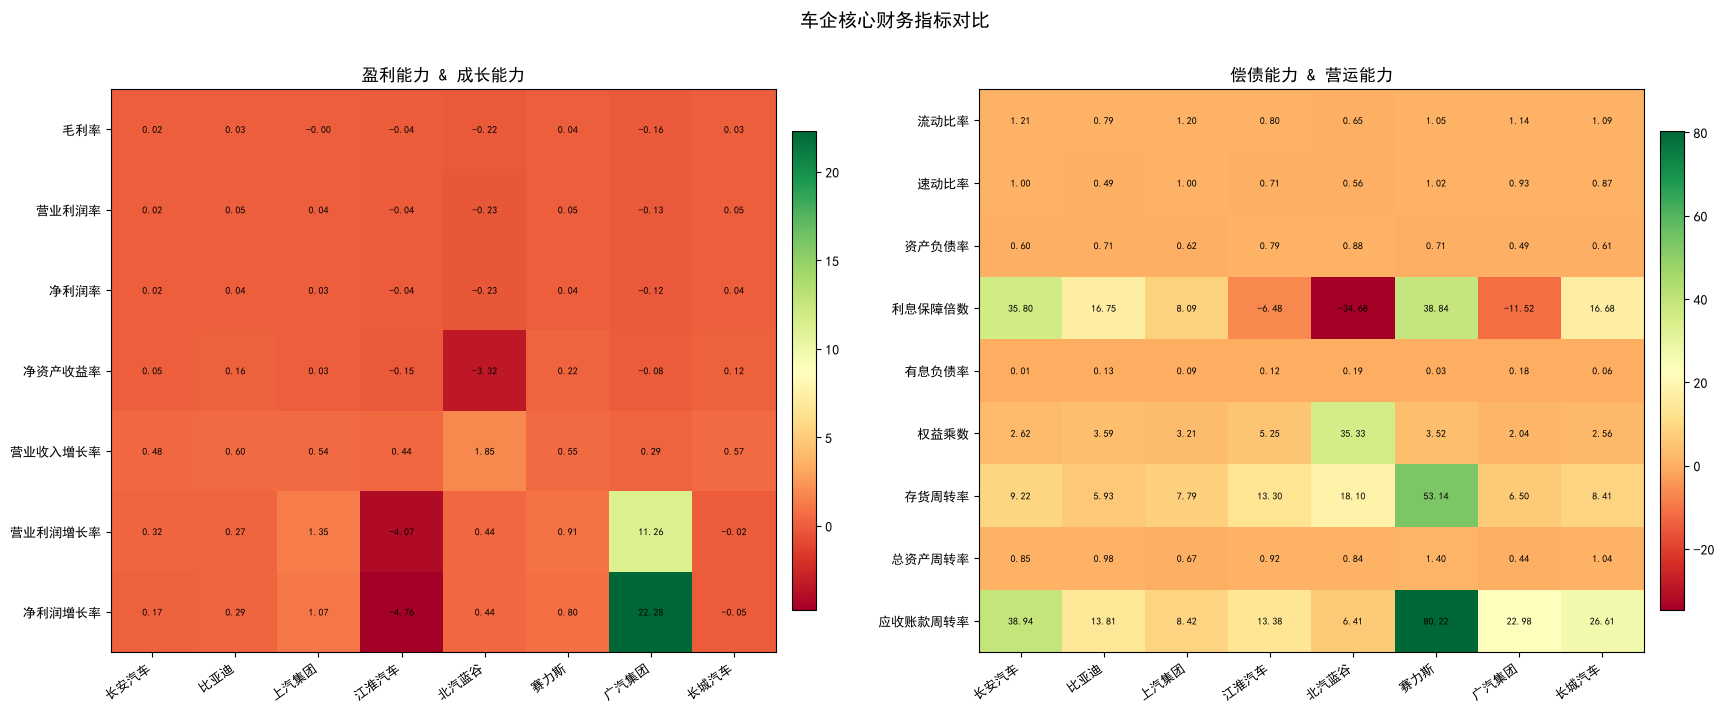

In [6]:
METRICS_LEFT  = ['毛利率','营业利润率','净利润率','净资产收益率','营业收入增长率','营业利润增长率','净利润增长率']
METRICS_RIGHT = ['流动比率','速动比率','资产负债率','利息保障倍数','有息负债率','权益乘数','存货周转率','总资产周转率','应收账款周转率']
ALL_METRICS = METRICS_LEFT + METRICS_RIGHT

summary = []
for code, df_r in all_ratios.items():
    name = code.split('_')[1]
    annual = [i for i in df_r.index if '年报' in str(i)]
    if not annual: continue
    latest = annual[-1]
    row = {'公司': name}
    for m in ALL_METRICS:
        row[m] = df_r.loc[latest, m] if latest in df_r.index and m in df_r.columns else None
    summary.append(row)

df_summary = pd.DataFrame(summary).set_index('公司')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

for ax, metrics, title in [ (ax1, METRICS_LEFT,  '盈利能力 & 成长能力'),(ax2, METRICS_RIGHT, '偿债能力 & 营运能力'),]:
    df_sub = df_summary[metrics]
    im = ax.imshow(df_sub.T, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(df_sub)))
    ax.set_xticklabels(df_sub.index, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(len(metrics)))
    ax.set_yticklabels(metrics, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    for i in range(len(metrics)):
        for j in range(len(df_sub)):
            val = df_sub.iloc[j, i]
            if pd.notna(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7.5)
    plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)

fig.suptitle('车企核心财务指标对比', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('reports/pictures/financial_metrics_comparison.png', dpi=100, bbox_inches='tight')
plt.tight_layout(); plt.show()

2.研发投入趋势 (赛力斯 vs 长安)

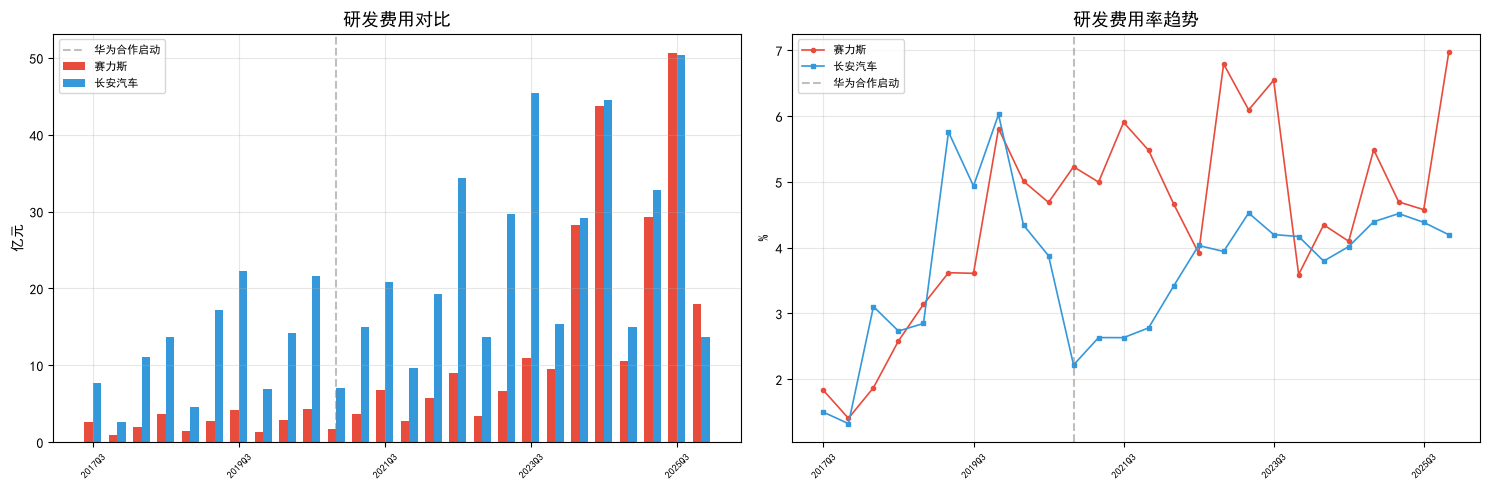


最新季度 — 赛力斯研发17.9亿(率7.0%)
 长安研发13.7亿(率4.2%)


In [7]:
def _rd(code):
    df = pd.read_excel(f'data/{code}_财务数据.xlsx', sheet_name='利润表', index_col=0)
    qs = [c for c in df.columns if 'Q' in str(c)]
    rs = []
    for q in qs:
        rd = pd.to_numeric(df.loc['研发费用', q], errors='coerce')
        rv = pd.to_numeric(df.loc['营业收入', q], errors='coerce')
        if pd.notna(rd) and pd.notna(rv) and rv > 0:
            rs.append({'季度': str(q), '研发费用(亿)': rd/1e8, '研发率(%)': rd/rv*100})
    return pd.DataFrame(rs)

sl = _rd('601127_赛力斯')
ca = _rd('000625_长安汽车')
if sl is not None and ca is not None:
    df_rd = sl.merge(ca, on='季度', suffixes=('_赛力斯', '_长安'))
    labels = df_rd['季度'].tolist()
    x = range(len(df_rd))
    hw = next((i for i,l in enumerate(labels) if '2021' in l), None)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    for ax, col, unit in [(ax1, '研发费用(亿)', '亿元'), (ax2, '研发率(%)', '%')]:
        if ax == ax1:   
            bar_width = 0.35
            ax.bar([p - bar_width/2 for p in x], df_rd[f'{col}_赛力斯'],
                   bar_width, color='#E74C3C', label='赛力斯')
            ax.bar([p + bar_width/2 for p in x], df_rd[f'{col}_长安'],
                   bar_width, color='#3498DB', label='长安汽车')
        else:
            ax.plot(x, df_rd[f'{col}_赛力斯'], 'o-', color='#E74C3C', lw=1.2, ms=3, label='赛力斯')
            ax.plot(x, df_rd[f'{col}_长安'], 's-', color='#3498DB', lw=1.2, ms=3, label='长安汽车')

        if hw is not None:
            ax.axvline(x=hw, color='gray', ls='--', alpha=.5, label='华为合作启动')
        ax.set_xticks([i for i in x if i%6==0])
        ax.set_xticklabels([labels[i] for i in x if i%6==0], rotation=45, fontsize=7)
        ax.set_ylabel(unit)
        ax.legend(fontsize=8)
        ax.grid(alpha=.3)

    ax1.set_title('研发费用对比', fontsize=13)
    ax2.set_title('研发费用率趋势', fontsize=13)
    plt.tight_layout()
    plt.savefig('reports/pictures/rd_expense_comparison.png', dpi=100, bbox_inches='tight')
    plt.show()

    l = df_rd.iloc[-1]
    print(f"\n最新季度 — 赛力斯研发{l['研发费用(亿)_赛力斯']:.1f}亿(率{l['研发率(%)_赛力斯']:.1f}%)")
    print(f" 长安研发{l['研发费用(亿)_长安']:.1f}亿(率{l['研发率(%)_长安']:.1f}%)")

<a id="sec-3"></a>

##### 三、财务分析

1. K-Means 聚类分析（8家车企风险分群，K=3）

  000625_长安汽车: 40 季度点
  002594_比亚迪: 39 季度点
  600104_上汽集团: 38 季度点
  600418_江淮汽车: 39 季度点
  600733_北汽蓝谷: 39 季度点
  601127_赛力斯: 41 季度点
  601238_广汽集团: 39 季度点
  601633_长城汽车: 39 季度点

季度数据集: 314 条 (8家x~39季度)
五维指标: ['毛利率', '经营现金流/营收', '有息负债率', '存货周转率', '权益乘数']


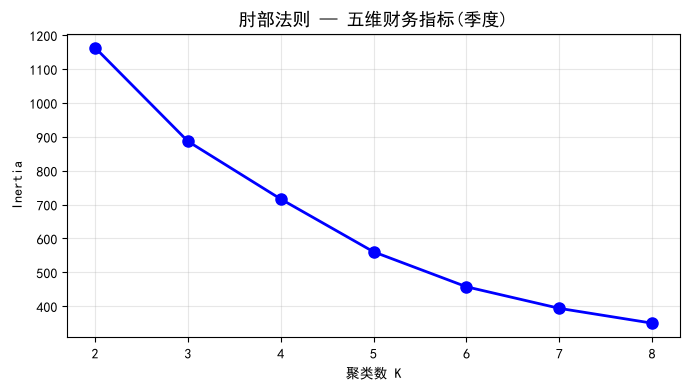

findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


  K-Means 聚类 (K=3, 314季度点)
  五维矩阵: 偿债+盈利+营运+现金流+杠杆
  群0 (8企/287季): 长安汽车, 比亚迪, 上汽集团, 江淮汽车, 北汽蓝谷, 赛力斯, 广汽集团, 长城汽车
    毛利率: -0.011
    经营现金流/营收: -0.020
    有息负债率: 0.124
    存货周转率: 7.954
    权益乘数: 3.104
  群1 (1企/3季): 北汽蓝谷
    毛利率: -1.075
    经营现金流/营收: -8.312
    有息负债率: 0.000
    存货周转率: 0.047
    权益乘数: 1.983
  群2 (1企/24季): 北汽蓝谷
    毛利率: -0.528
    经营现金流/营收: -0.208
    有息负债率: 0.382
    存货周转率: 4.533
    权益乘数: 7.285

--- 各企业综合风险评分（五维矩阵） ---
  ⚠️ 赛力斯: 0.692
  ⚠️ 长安汽车: 0.674
  ⚠️ 北汽蓝谷: 0.663
  ⚠️ 广汽集团: 0.634
  ⚠️ 比亚迪: 0.571
  ⚠️ 上汽集团: 0.547
  ⚠️ 江淮汽车: 0.539
  ✅ 长城汽车: 0.483

  轮廓系数: 0.609  CH指数: 119.8


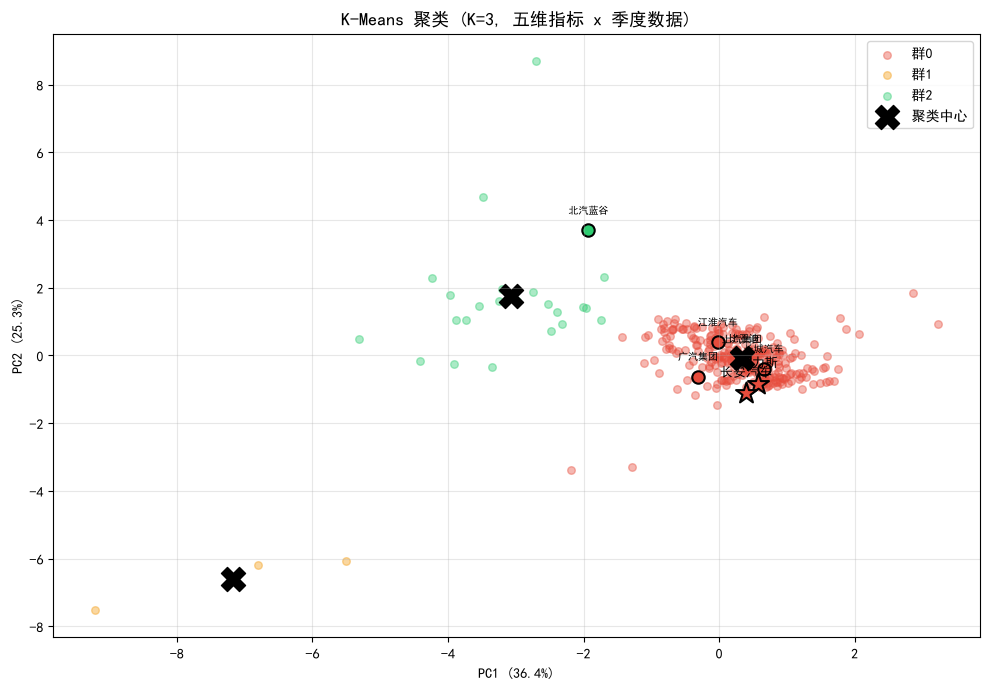

In [8]:
import os; os.environ['LOKY_MAX_CPU_COUNT'] = '4'
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
FEATURES = ['毛利率','经营现金流/营收','有息负债率','存货周转率','权益乘数'] 

# 季度数据构建
def _qdf(code):
    fp = f'data/{code}_财务数据.xlsx'
    xl = pd.ExcelFile(fp)
    if '合并报表' not in xl.sheet_names: return None
    m = pd.read_excel(xl,'合并报表',index_col=0)
    name = code.split('_')[1]
    rs = []
    for p in m.index:
        # 毛利率
        rev = m.loc[p,'营业收入_利润'] if '营业收入_利润' in m.columns else np.nan
        cost = m.loc[p,'营业成本_利润'] if '营业成本_利润' in m.columns else np.nan
        gm = 1 - cost/rev if (pd.notna(rev) and pd.notna(cost) and rev!=0) else np.nan
        # 经营现金流/营收
        ocf_cols = [c for c in m.columns if '经营' in c and '现金流' in c and '净额' in c]
        ocf = m.loc[p,ocf_cols[0]] if ocf_cols else np.nan
        ocf_r = ocf/rev if (pd.notna(ocf) and pd.notna(rev) and rev!=0) else np.nan
        # 有息负债率: (短期借款+长期借款+应付债券+一年内到期非流动负债)/总资产
        ib_keys = ['短期借款_资产','长期借款_资产','应付债券_资产','一年内到期的非流动负债_资产']
        ib = 0; ta = np.nan
        if '资产合计_资产' in m.columns:
            ta = m.loc[p,'资产合计_资产']
        for k in ib_keys:
            if k in m.columns:
                v = pd.to_numeric(m.loc[p,k], errors='coerce')
                if pd.notna(v): ib += v
        idr = ib/ta if (pd.notna(ta) and ta!=0) else np.nan
        # 存货周转率 & 权益乘数
        it = np.nan; em = np.nan
        # 权益乘数 = 总资产/归母权益
        if '资产合计_资产' in m.columns and '归属于母公司所有者权益合计_资产' in m.columns:
            eq = m.loc[p,'归属于母公司所有者权益合计_资产']
            ta2 = m.loc[p,'资产合计_资产']
            em = ta2/eq if (pd.notna(eq) and pd.notna(ta2) and eq!=0) else np.nan
        # 存货周转率: 优先从all_ratios获取
        if code in all_ratios and p in all_ratios[code].index:
            ar = all_ratios[code].loc[p]
            it = ar.get('存货周转率',np.nan)
        elif '存货_资产' in m.columns and '营业成本_利润' in m.columns:
            inv_cur = m.loc[p,'存货_资产']
            prev_idx = m.index.get_loc(p)-1
            if prev_idx >= 0:
                inv_prev = m.iloc[prev_idx]['存货_资产']
                it = cost/((inv_cur+inv_prev)/2) if (pd.notna(cost) and pd.notna(inv_cur) and pd.notna(inv_prev) and (inv_cur+inv_prev)!=0) else np.nan
        rs.append({'code':code,'name':name,'period':p,
                   '毛利率':gm,'经营现金流/营收':ocf_r,'有息负债率':idr,
                   '存货周转率':it,'权益乘数':em})
    return pd.DataFrame(rs).dropna()

dfs = []
for fp in Path('data').glob('*_财务数据.xlsx'):
    code = fp.stem.replace('_财务数据','')
    df = _qdf(code)
    if df is not None and len(df) > 0:
        dfs.append(df)
        print(f'  {code}: {len(df)} 季度点')
df_kmeans = pd.concat(dfs, ignore_index=True)
print(f'\n季度数据集: {len(df_kmeans)} 条 (8家x~{len(df_kmeans)//8}季度)')
print(f'五维指标: {FEATURES}')

X = df_kmeans[FEATURES].values
X_scaled = StandardScaler().fit_transform(X)

# 肘部法则
inertias = []; K_range = range(2,min(9,len(df_kmeans)//4))
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10); km.fit(X_scaled)
    inertias.append(km.inertia_)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(K_range, inertias, 'bo-', lw=2, ms=8)
ax.set_xlabel('聚类数 K'); ax.set_ylabel('Inertia')
ax.set_title('肘部法则 — 五维财务指标(季度)', fontsize=13)
ax.grid(alpha=0.3); plt.tight_layout(); plt.savefig('reports/pictures/elbow_method.png', dpi=150, bbox_inches='tight'); plt.show()

OPTIMAL_K = 3
km = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_kmeans['cluster'] = km.fit_predict(X_scaled)

print('='*60)
print(f'  K-Means 聚类 (K={OPTIMAL_K}, {len(df_kmeans)}季度点)')
print(f'  五维矩阵: 偿债+盈利+营运+现金流+杠杆')
print('='*60)
for c in range(OPTIMAL_K):
    mask = df_kmeans['cluster']==c
    members = df_kmeans[mask]['name'].unique()
    avg = df_kmeans[mask][FEATURES].mean()
    print(f'  群{c} ({len(members)}企/{mask.sum()}季): {", ".join(members)}')
    for f in FEATURES:
        print(f'    {f}: {avg[f]:.3f}')

# 综合风险评分
df_kmeans['risk_score'] = (
    (1-df_kmeans['毛利率'].clip(upper=0.5))*0.15+
    (1-df_kmeans['经营现金流/营收'].clip(upper=2))*0.25+
    df_kmeans['有息负债率'].clip(upper=1)*0.25+
    (1-df_kmeans['存货周转率'].clip(upper=15)/15)*0.15+
    df_kmeans['权益乘数'].clip(upper=10)/10*0.20
)
# 按公司汇总
latest_risk = df_kmeans.sort_values('period').groupby('name').last()['risk_score'].sort_values(ascending=False)
print('\n--- 各企业综合风险评分（五维矩阵） ---')
for name, score in latest_risk.items():
    icon = '🔴' if score>0.7 else ('⚠️' if score>0.5 else '✅')
    print(f'  {icon} {name}: {score:.3f}')

# 聚类评估
sil = silhouette_score(X_scaled, df_kmeans['cluster'])
ch = calinski_harabasz_score(X_scaled, df_kmeans['cluster'])
print(f'\n  轮廓系数: {sil:.3f}  CH指数: {ch:.1f}')

# PCA可视化
pca = PCA(n_components=2); X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E74C3C','#F39C12','#2ECC71'][:OPTIMAL_K]
for c in range(OPTIMAL_K):
    mask = df_kmeans['cluster']==c
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=colors[c], s=30, alpha=0.4, label=f'群{c}')
for i, row in df_kmeans.groupby('name').last().iterrows():
    idx = df_kmeans[df_kmeans['name']==i].index[-1]
    is_core = i in ['赛力斯','长安汽车']
    ax.scatter(X_pca[idx,0], X_pca[idx,1], c=colors[row['cluster']], s=250 if is_core else 80,
               marker='*' if is_core else 'o', edgecolors='black', linewidths=1.5)
    ax.annotate(i, (X_pca[idx,0], X_pca[idx,1]), fontsize=9 if is_core else 7, ha='center',
                xytext=(0,12), textcoords='offset points', fontweight='bold' if is_core else 'normal')
centers_pca = pca.transform(km.cluster_centers_)
ax.scatter(centers_pca[:,0], centers_pca[:,1], c='black', marker='X', s=300, label='聚类中心')
ax.set_title(f'K-Means 聚类 (K={OPTIMAL_K}, 五维指标 x 季度数据)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); 
plt.savefig('reports/pictures/kmeans_pca.png', dpi=100, bbox_inches='tight')
plt.show()

2. 孤立森林异常检测

C:\Users\yohoten\AppData\Local\Temp\ipykernel_31520\3716346525.py:58: UserWarning: Glyph 10004 (\N{HEAVY CHECK MARK}) missing from font(s) SimHei.
  plt.savefig('reports/pictures/anomaly_boxplot.png', dpi=100, bbox_inches='tight')
f:\FIDAC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10004 (\N{HEAVY CHECK MARK}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


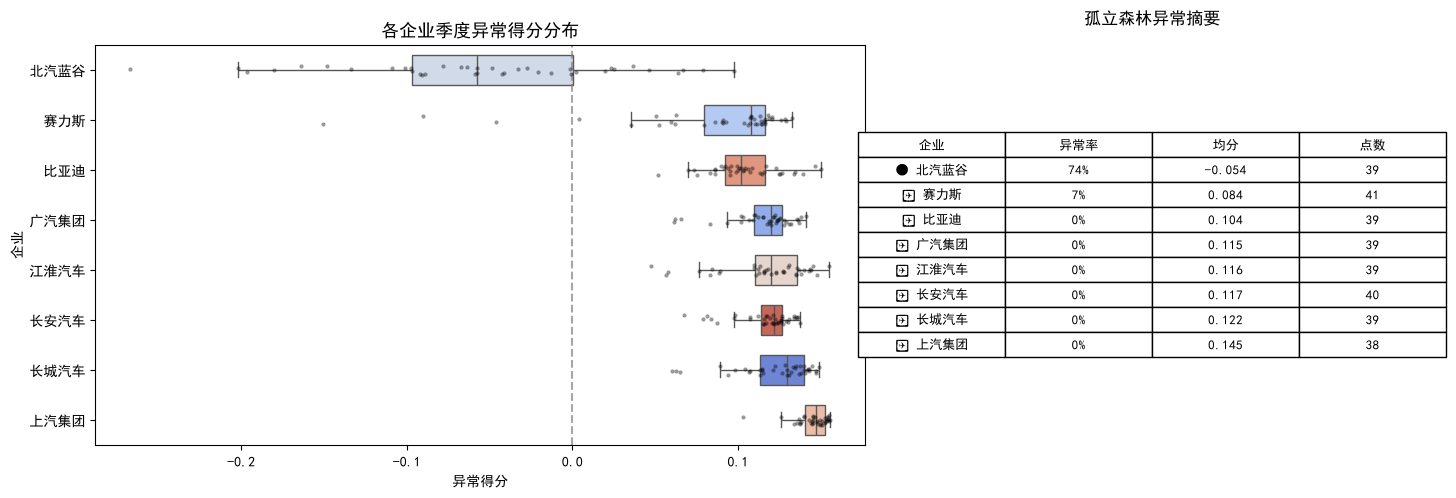

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

FEATURES = ['毛利率','经营现金流/营收','有息负债率','存货周转率','权益乘数']
iso = IsolationForest(contamination=0.1, random_state=42, n_estimators=200)
df_kmeans['anomaly_label'] = iso.fit_predict(df_kmeans[FEATURES].values)
df_kmeans['anomaly_score'] = iso.decision_function(df_kmeans[FEATURES].values)

# 按企业汇总异常摘要
anomaly_summary = (
    df_kmeans.groupby('name')
    .agg(anomaly_rate=('anomaly_label', lambda s: (s == -1).mean()),
         avg_score=('anomaly_score', 'mean'),
         point_count=('anomaly_score', 'size'))
    .sort_values('avg_score')
)
name_order = anomaly_summary.index.tolist()
fig = plt.figure(figsize=(14, 5))
#left
ax_box = fig.add_axes([0.05, 0.1, 0.55, 0.8])
sns.boxplot(data=df_kmeans, y='name', x='anomaly_score',
            order=name_order, hue='name', palette='coolwarm_r',
            legend=False, width=0.6, fliersize=0, ax=ax_box)
sns.stripplot(data=df_kmeans, y='name', x='anomaly_score',
              order=name_order, color='black', alpha=0.4, size=3, jitter=True, ax=ax_box)
ax_box.axvline(x=0, color='gray', ls='--', alpha=0.7)
ax_box.set_xlabel('异常得分')
ax_box.set_ylabel('企业')
ax_box.set_title('各企业季度异常得分分布', fontsize=13)
# right
ax_table = fig.add_axes([0.63, 0.1, 0.35, 0.8])
ax_table.axis('off')

table_data = []
for name, row in anomaly_summary.iterrows():
    if row['anomaly_rate'] > 0.3:
        flag = '●'      # 高风险
    elif row['anomaly_rate'] > 0.1:
        flag = '▲'      # 中等关注
    else:
        flag = '✔'      # 正常
    table_data.append([
        f'{flag} {name}',
        f'{row["anomaly_rate"]*100:.0f}%',
        f'{row["avg_score"]:.3f}',
        str(int(row['point_count']))
    ])

col_labels = ['企业', '异常率', '均分', '点数']
table = ax_table.table(cellText=table_data, colLabels=col_labels,
                       loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
ax_table.set_title('孤立森林异常摘要', fontsize=12, pad=15)
plt.savefig('reports/pictures/anomaly_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()

3. 指标时序预测（赛力斯 vs 长安）

（1）Prophet 时序预测

f:\FIDAC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.



  赛力斯（未来4个季度预测）


20:43:20 - cmdstanpy - INFO - Chain [1] start processing
20:43:20 - cmdstanpy - INFO - Chain [1] done processing
findfont: Failed to find font weight bold, now using 400.


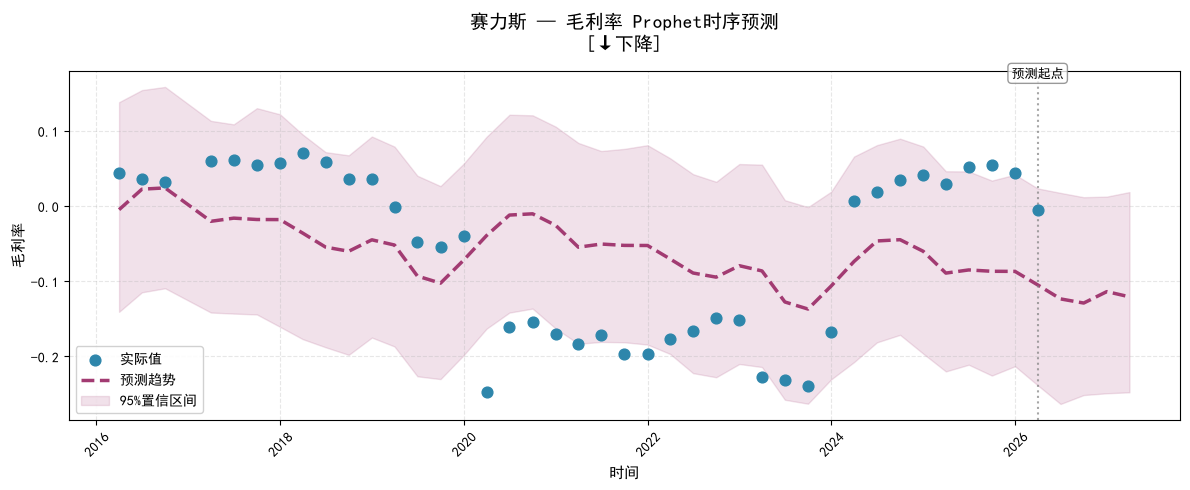

20:43:21 - cmdstanpy - INFO - Chain [1] start processing


  赛力斯 毛利率: ↓下降
    当前: -0.0046 → 预测: -0.1206 (-2521.6%)


20:43:21 - cmdstanpy - INFO - Chain [1] done processing


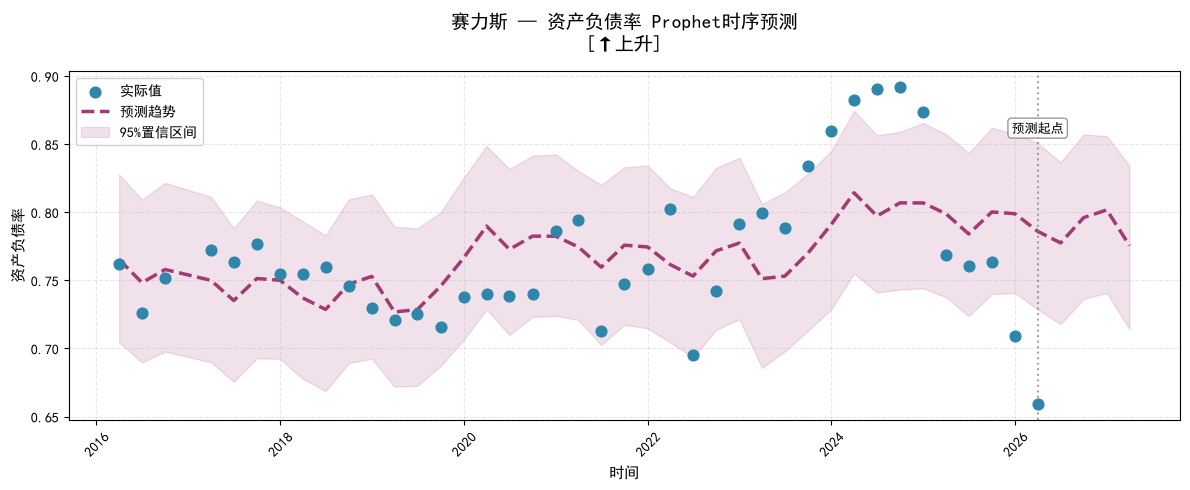

20:43:22 - cmdstanpy - INFO - Chain [1] start processing


  赛力斯 资产负债率: ↑上升
    当前: 0.6592 → 预测: 0.7755 (+17.6%)

  长安汽车（未来4个季度预测）


20:43:22 - cmdstanpy - INFO - Chain [1] done processing


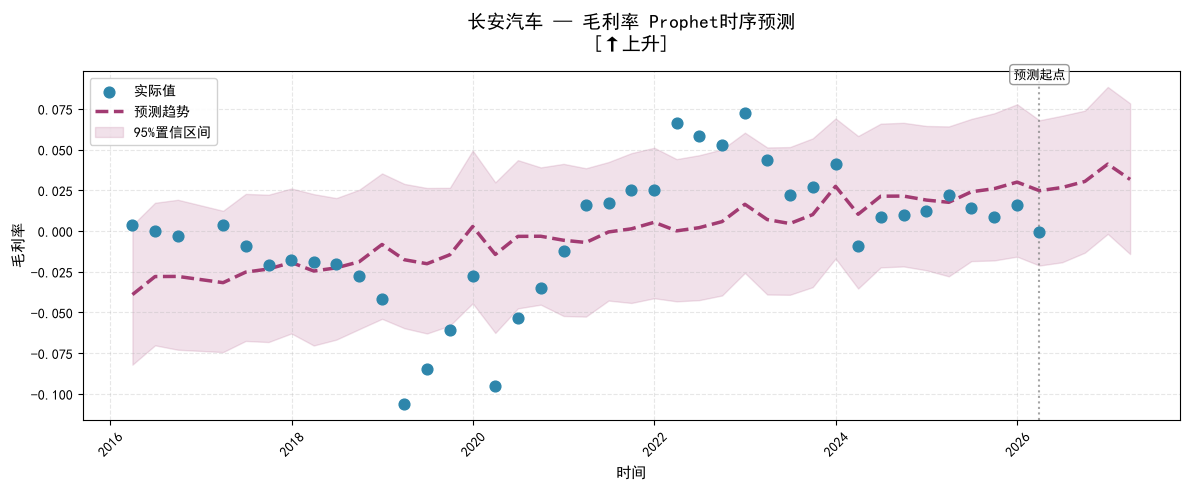

20:43:23 - cmdstanpy - INFO - Chain [1] start processing


  长安汽车 毛利率: ↑上升
    当前: -0.0006 → 预测: 0.0317 (+5706.6%)


20:43:24 - cmdstanpy - INFO - Chain [1] done processing


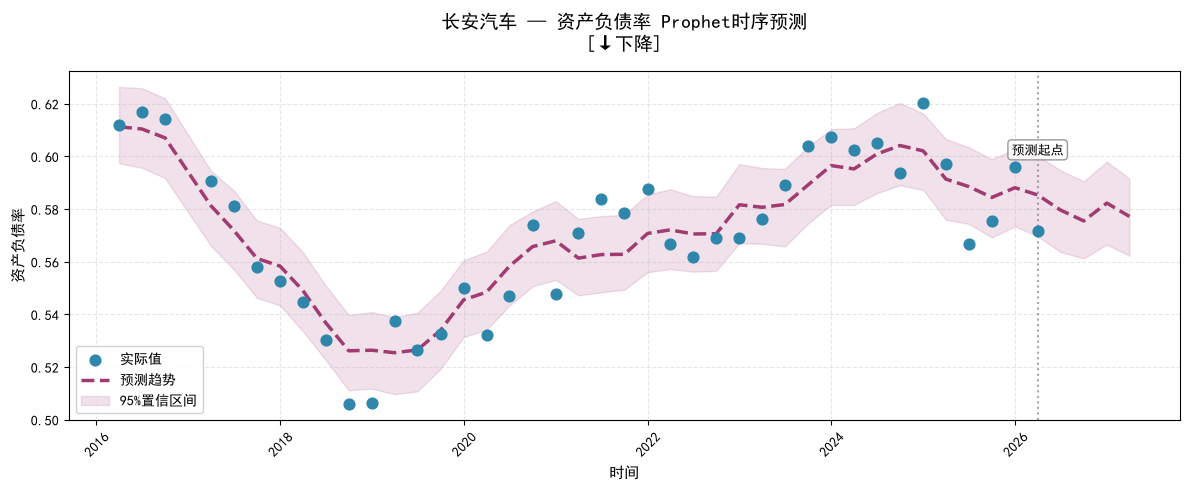

  长安汽车 资产负债率: ↓下降
    当前: 0.5715 → 预测: 0.5771 (+1.0%)

  Prophet 季度预测摘要
  赛力斯 毛利率: 2026Q1预测值=-0.1047
  赛力斯 资产负债率: 2026Q1预测值=0.7860
  长安汽车 毛利率: 2026Q1预测值=0.0248
  长安汽车 资产负债率: 2026Q1预测值=0.5853


In [10]:
import os, tempfile, logging, tqdm as tqdm
from prophet import Prophet

CLEAN_DIR = os.path.join(tempfile.gettempdir(), 'prophet_work')
os.makedirs(CLEAN_DIR, exist_ok=True)
for var in ['TMPDIR', 'TEMP', 'TMP']:
    os.environ[var] = CLEAN_DIR

_orig_cwd = os.getcwd()
os.chdir(CLEAN_DIR)

logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

def prophet_forecast(code, metric_col, forecast_quarters=4):
    if code not in all_ratios:
        return None
    
    df_p = all_ratios[code][[metric_col]].reset_index()
    df_p['ds'] = pd.to_datetime(
        df_p['index'].str.replace('年报', '-12-31')
                     .str.replace('Q1', '-03-31')
                     .str.replace('Q2', '-06-30')
                     .str.replace('Q3', '-09-30'),
        errors='coerce')
    df_p = df_p.rename(columns={metric_col: 'y'}).dropna().query('y != 0')
    
    if len(df_p) < 10:
        return None
    
    m = Prophet(growth='linear', yearly_seasonality=True, seasonality_mode='additive')
    m.fit(df_p[['ds', 'y']])
    
    future = m.make_future_dataframe(periods=forecast_quarters, freq='QE')
    forecast = m.predict(future)
    
    direction = '↑上升' if forecast['trend'].iloc[-1] > forecast[forecast['ds'] <= df_p['ds'].max()]['trend'].iloc[-1] else '↓下降'
    change_pct = (forecast['yhat'].iloc[-1] - df_p['y'].iloc[-1]) / abs(df_p['y'].iloc[-1]) * 100
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.scatter(df_p['ds'], df_p['y'], color='#2E86AB', s=60, label='实际值', zorder=3)
    ax.plot(forecast['ds'], forecast['yhat'], '--', color='#A23B72', linewidth=2.5, label='预测趋势', zorder=2)
    ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                     color='#A23B72', alpha=0.15, label='95%置信区间', zorder=1)
    
    ax.axvline(x=df_p['ds'].max(), color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.text(df_p['ds'].max(), ax.get_ylim()[1]*0.95, '预测起点', fontsize=9, ha='center', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    
    ax.set_title(f'{code.split("_")[1]} — {metric_col} Prophet时序预测\n[{direction}]', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('时间', fontsize=11)
    ax.set_ylabel(metric_col, fontsize=11)
    ax.legend(loc='best', framealpha=0.9, fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{code}_{metric_col}_forecast.png', dpi=80, bbox_inches='tight')
    plt.show()
    
    print(f'  {code.split("_")[1]} {metric_col}: {direction}')
    print(f'    当前: {df_p["y"].iloc[-1]:.4f} → 预测: {forecast["yhat"].iloc[-1]:.4f} ({change_pct:+.1f}%)')
    return forecast

prophet_results = {}
for code in ['601127_赛力斯', '000625_长安汽车']:
    if code not in all_ratios: continue
    print(f'\n{"="*50}\n  {code.split("_")[1]}（未来4个季度预测）\n{"="*50}')
    for metric in ['毛利率', '资产负债率']:
        fc = prophet_forecast(code, metric, forecast_quarters=4)
        if fc is not None:
            prophet_results[(code, metric)] = fc

print(f'\n{"="*60}\n  Prophet 季度预测摘要\n{"="*60}')
for (code, metric), fc in prophet_results.items():
    pred = fc[fc['ds'] == '2026-03-31']
    if len(pred):
        print(f'  {code.split("_")[1]} {metric}: 2026Q1预测值={pred["yhat"].values[0]:.4f}')

os.chdir(_orig_cwd)

* Prophet 预测出极端值（毛利率变负）很可疑，仅有 ~20 个有效数据点，且 yearly_seasonality=True 对小样本极易过拟合；
* 财务指标通常具有明显的周期性和结构性变化，用 Prophet 做趋势方向判断而非精确数值预测；

（2）预测模型对比

`综合分 = R²排名百分位×35% + (1-MAPE排名百分位)×45% + (1-σ排名百分位)×20%`


  赛力斯 - 毛利率


findfont: Failed to find font weight bold, now using 400.
C:\Users\yohoten\AppData\Local\Temp\ipykernel_31520\3071284874.py:69: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
findfont: Failed to find font weight bold, now using 400.
C:\Users\yohoten\AppData\Local\Temp\ipykernel_31520\3071284874.py:71: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig(out, dpi=100, bbox_inches='tight')
f:\FIDAC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


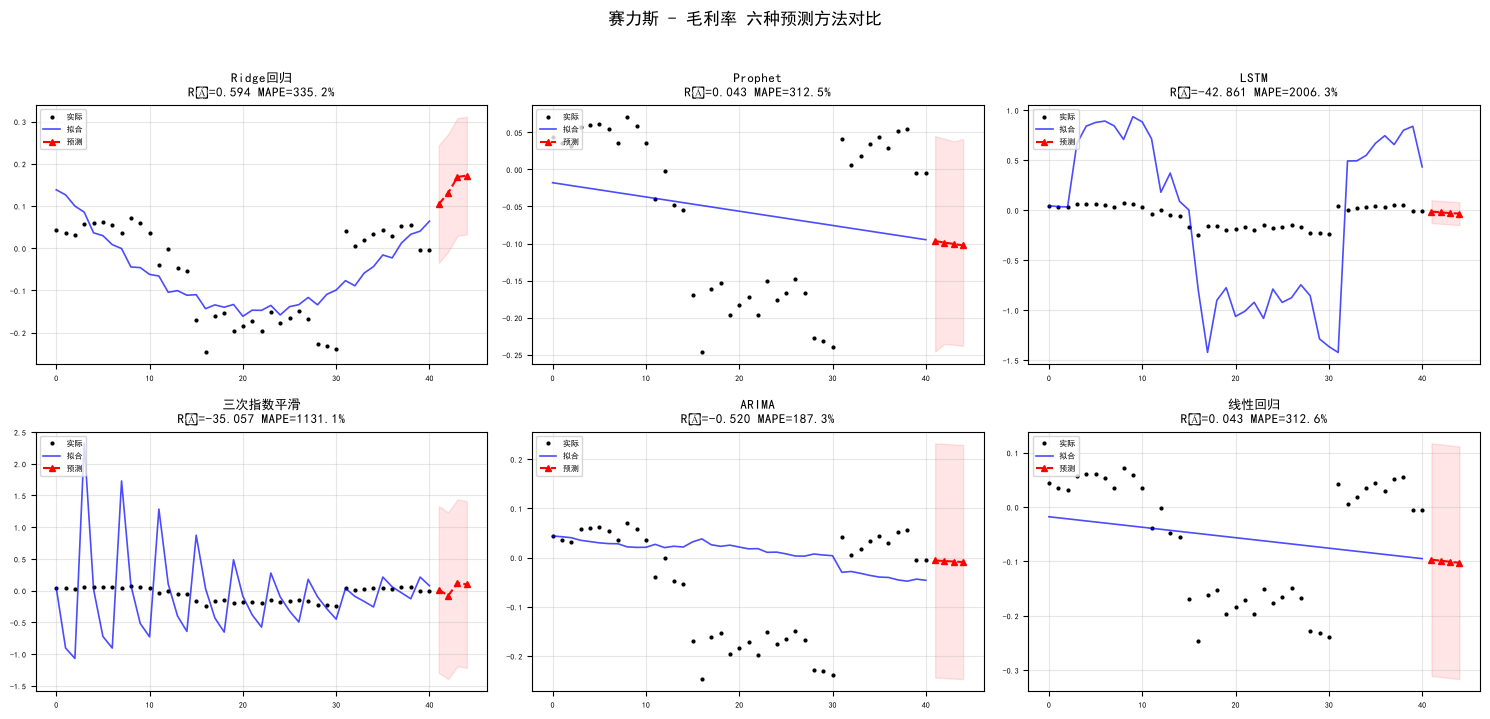


赛力斯 - 毛利率 预测方法对比排名
  🥇. Ridge回归    R²=0.594 MAPE=335.2% σ=0.0697 综合分=63.3
  🥈. 线性回归       R²=0.043 MAPE=312.6% σ=0.1070 综合分=61.7
  🥉. Prophet    R²=0.043 MAPE=312.5% σ=0.1071 综合分=60.0
   4. ARIMA      R²=-0.520 MAPE=187.3% σ=0.1190 综合分=58.3
   5. LSTM       R²=-42.861 MAPE=2006.3% σ=0.0571 综合分=22.5
   6. 三次指数平滑     R²=-35.057 MAPE=1131.1% σ=0.6572 综合分=19.2

  ✅ 最优方法: Ridge回归 (综合分=63.3)

  赛力斯 - 资产负债率


C:\Users\yohoten\AppData\Local\Temp\ipykernel_31520\3071284874.py:69: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\yohoten\AppData\Local\Temp\ipykernel_31520\3071284874.py:71: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig(out, dpi=100, bbox_inches='tight')
f:\FIDAC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


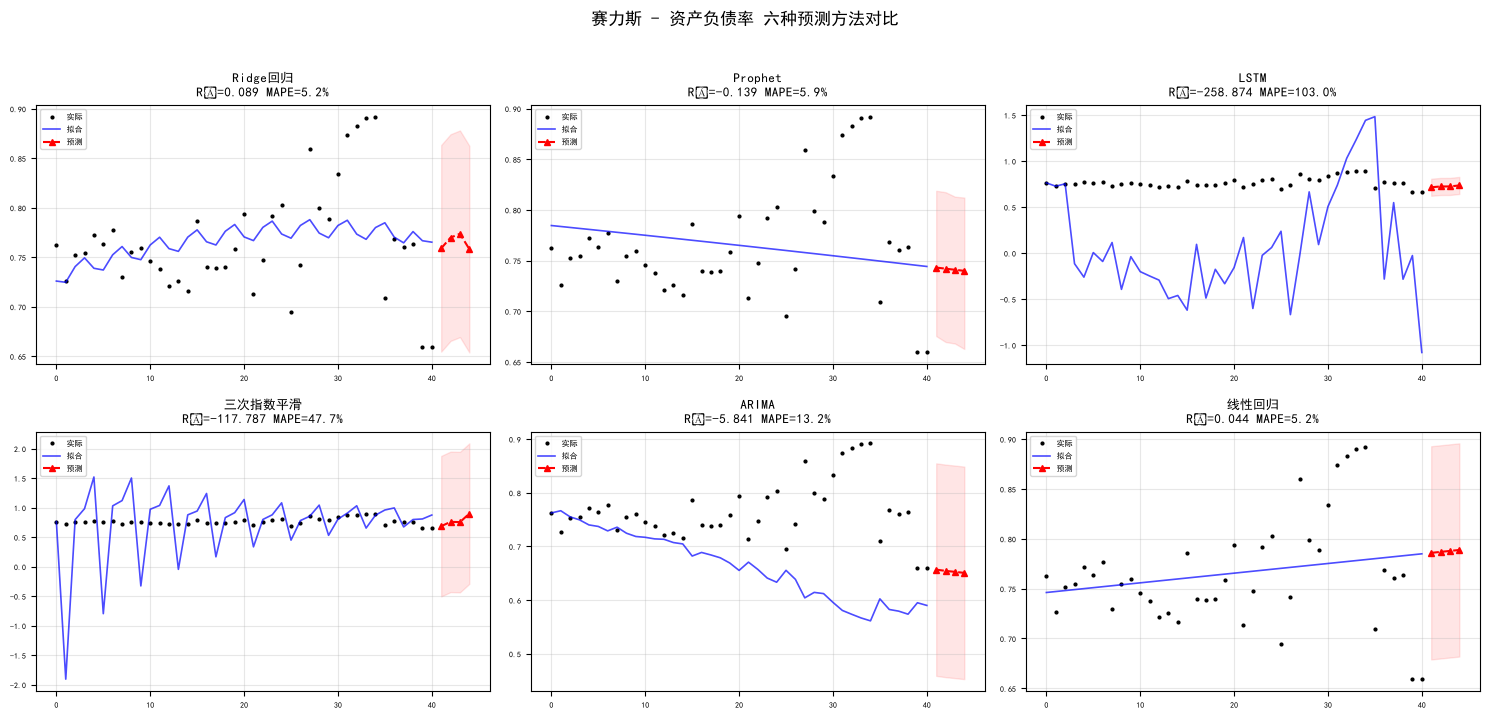


赛力斯 - 资产负债率 预测方法对比排名
  🥇. Ridge回归    R²=0.089 MAPE=5.2% σ=0.0522 综合分=78.3
  🥈. 线性回归       R²=0.044 MAPE=5.2% σ=0.0535 综合分=76.7
  🥉. Prophet    R²=-0.139 MAPE=5.9% σ=0.0583 综合分=52.5
   4. ARIMA      R²=-5.841 MAPE=13.2% σ=0.0990 综合分=35.8
   5. LSTM       R²=-258.874 MAPE=103.0% σ=0.0464 综合分=22.5
   6. 三次指数平滑     R²=-117.787 MAPE=47.7% σ=0.5953 综合分=19.2

  ✅ 最优方法: Ridge回归 (综合分=78.3)

  长安汽车 - 毛利率


C:\Users\yohoten\AppData\Local\Temp\ipykernel_31520\3071284874.py:69: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\yohoten\AppData\Local\Temp\ipykernel_31520\3071284874.py:71: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig(out, dpi=100, bbox_inches='tight')
f:\FIDAC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


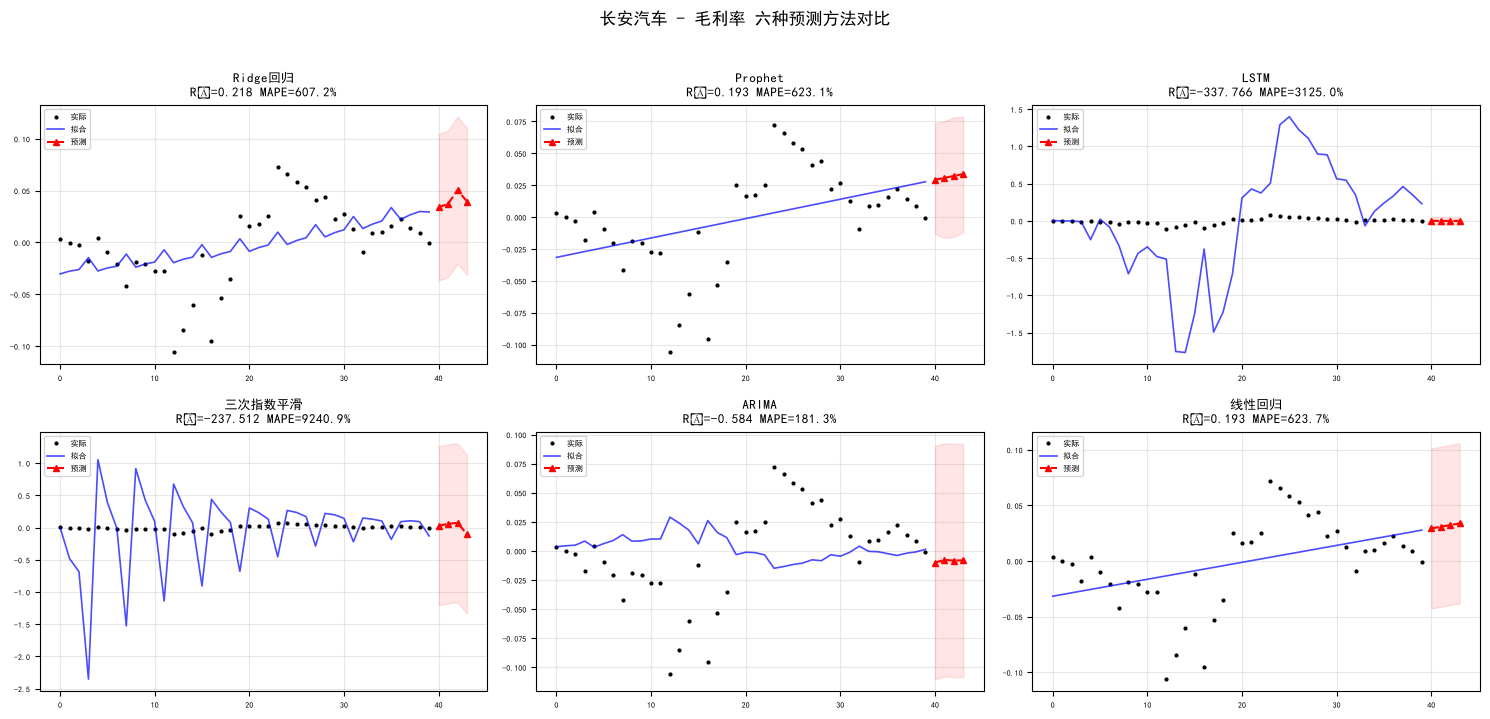


长安汽车 - 毛利率 预测方法对比排名
  🥇. Ridge回归    R²=0.218 MAPE=607.2% σ=0.0354 综合分=78.3
  🥈. Prophet    R²=0.193 MAPE=623.1% σ=0.0360 综合分=61.7
  🥉. ARIMA      R²=-0.584 MAPE=181.3% σ=0.0501 综合分=58.3
   4. 线性回归       R²=0.193 MAPE=623.7% σ=0.0360 综合分=45.0
   5. LSTM       R²=-337.766 MAPE=3125.0% σ=0.0259 综合分=30.0
   6. 三次指数平滑     R²=-237.512 MAPE=9240.9% σ=0.6167 综合分=11.7

  ✅ 最优方法: Ridge回归 (综合分=78.3)

  长安汽车 - 资产负债率


C:\Users\yohoten\AppData\Local\Temp\ipykernel_31520\3071284874.py:69: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\yohoten\AppData\Local\Temp\ipykernel_31520\3071284874.py:71: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig(out, dpi=100, bbox_inches='tight')
f:\FIDAC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


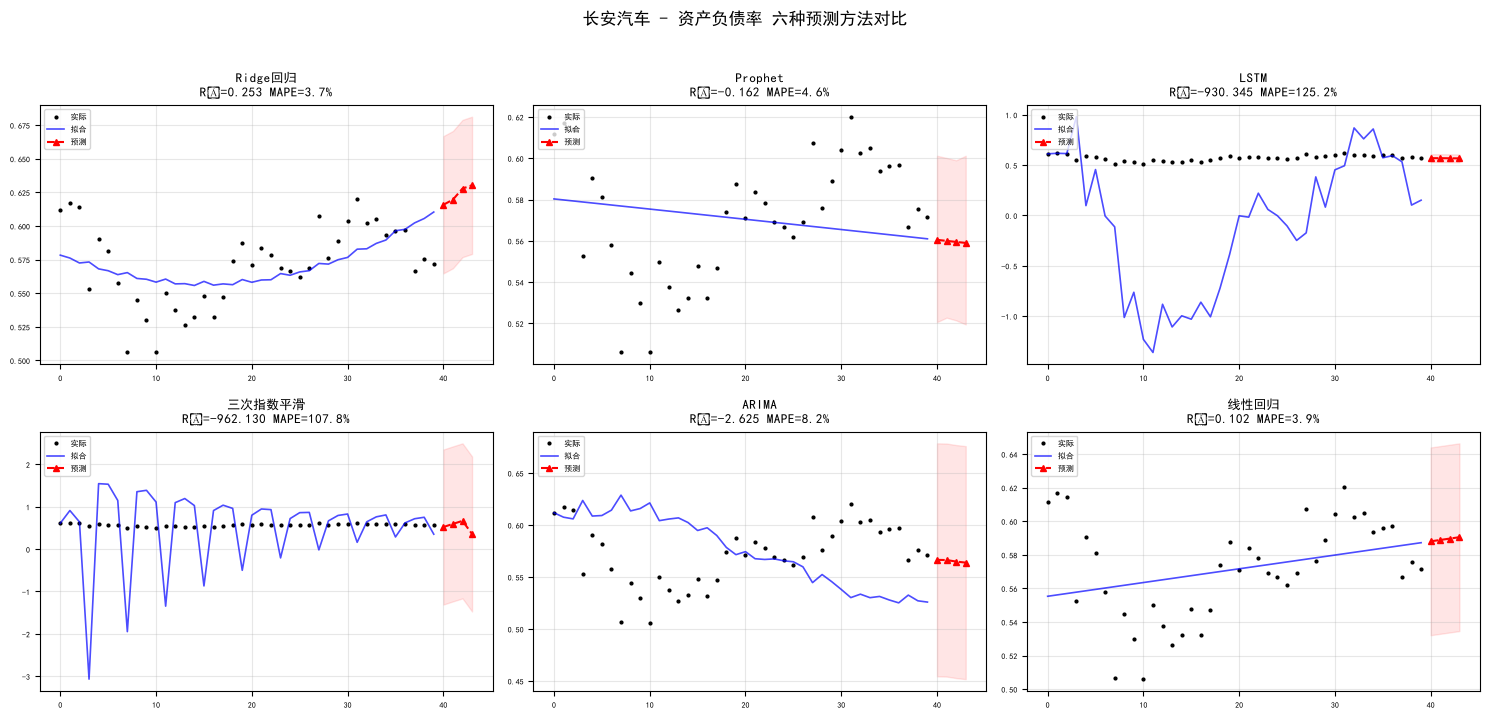


长安汽车 - 资产负债率 预测方法对比排名
  🥇. Ridge回归    R²=0.253 MAPE=3.7% σ=0.0255 综合分=85.8
  🥈. 线性回归       R²=0.102 MAPE=3.9% σ=0.0280 综合分=69.2
  🥉. Prophet    R²=-0.162 MAPE=4.6% σ=0.0318 综合分=52.5
   4. ARIMA      R²=-2.625 MAPE=8.2% σ=0.0560 综合分=35.8
   5. LSTM       R²=-930.345 MAPE=125.2% σ=0.0198 综合分=28.3
   6. 三次指数平滑     R²=-962.130 MAPE=107.8% σ=0.9149 综合分=13.3

  ✅ 最优方法: Ridge回归 (综合分=85.8)


In [11]:
from __future__ import annotations

import itertools, math
from lib.financial_metrics import (
    compare_all_forecasts, compute_forecast_metrics, load_all_ratios,
)

CODES = ['601127_赛力斯', '000625_长安汽车']
METRICS = ['毛利率', '资产负债率']
FORECAST_Q = 4
MIN_SAMPLES = 8
COLS = 3
OUT_DIR = Path('reports/pictures')
RANK_ICON = {0: '🥇', 1: '🥈', 2: '🥉'}


def _fit_aligned(y: np.ndarray, fit_vals: np.ndarray) -> tuple:
    """将拟合值对齐到实际序列末端, 返回 (对齐后的实际值, 拟合起点下标)"""
    n, fit_len = len(y), len(fit_vals)
    start = n - fit_len if fit_len < n else 0
    return y[start:], start


def _score(df: pd.DataFrame) -> pd.DataFrame:
    """综合评分: R²(35%) 越高越好, MAPE(45%)/σ(20%) 越低越好 (百分位归一化)"""
    df = df.copy()
    df['score_r2'] = df['R²'].rank(pct=True) * 35
    df['score_mape'] = (1 - df['MAPE'].rank(pct=True)) * 45
    df['score_sigma'] = (1 - df['σ'].rank(pct=True)) * 20
    df['综合分'] = df[['score_r2', 'score_mape', 'score_sigma']].sum(axis=1)
    return df.sort_values('综合分', ascending=False).reset_index(drop=True)


def _plot_compare(series, results, df_metrics, name, metric_col, forecast_q):
    """绘制各方法 实际/拟合/预测 对比子图"""
    y = series.values
    n = len(y)
    n_methods = len(results)
    rows = math.ceil(n_methods / COLS)
    lookup = df_metrics.set_index('方法')

    fig, axes = plt.subplots(rows, COLS, figsize=(15, 3.5 * rows), squeeze=False)
    axes = axes.ravel()

    for i, (mname, res) in enumerate(results.items()):
        ax = axes[i]
        fit_vals = res['history_fit']
        _, start = _fit_aligned(y, fit_vals)
        x_fit, x_future = range(start, n), range(n, n + forecast_q)

        ax.plot(range(n), y, 'k.', ms=4, label='实际')
        ax.plot(x_fit, fit_vals, 'b-', lw=1.2, alpha=0.7, label='拟合')
        ax.plot(x_future, res['forecast'], 'r^--', ms=5, label='预测')
        ax.fill_between(x_future, res['forecast_lower'], res['forecast_upper'],
                        color='r', alpha=0.1)

        row = lookup.loc[mname]
        ax.set_title(f'{mname}\nR²={row["R²"]:.3f} MAPE={row["MAPE"]:.1f}%',
                     fontsize=9, fontweight='bold')
        ax.legend(fontsize=6, loc='upper left')
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=6)

    for ax in axes[n_methods:]:          # 隐藏多余子图
        ax.set_visible(False)

    fig.suptitle(f'{name} - {metric_col} 六种预测方法对比',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    out = OUT_DIR / f'forecast_6method_{name}_{metric_col}.png'
    plt.savefig(out, dpi=100, bbox_inches='tight')
    plt.show()


def run_6method_comparison(code, metric_col, forecast_q=FORECAST_Q, all_ratios=None):
    name = code.split('_')[1]
    df_ratio = all_ratios.get(code)
    if df_ratio is None:
        print(f'{code}: 无数据')
        return None, None
    series = df_ratio[metric_col].replace(0, np.nan).dropna()
    if len(series) < MIN_SAMPLES:
        print(f'{name} {metric_col}: 数据不足 ({len(series)})')
        return None, None

    results = compare_all_forecasts(series, forecast_q)
    if not results:
        print(f'{name} {metric_col}: 所有方法均失败')
        return None, None

    # 评估指标表
    rows = []
    for mname, res in results.items():
        y_sub, _ = _fit_aligned(series.values, res['history_fit'])
        m = compute_forecast_metrics(y_sub, res['history_fit'])
        m.update({'方法': mname, '预测终值': res['forecast'][-1], 'σ': res['sigma']})
        rows.append(m)
    df_metrics = _score(pd.DataFrame(rows))

    _plot_compare(series, results, df_metrics, name, metric_col, forecast_q)

    # 打印排名
    print(f'\n{name} - {metric_col} 预测方法对比排名')
    print('=' * 80)
    for i, row in df_metrics.iterrows():
        icon = RANK_ICON.get(i, f' {i + 1}')
        print(f'  {icon}. {row["方法"]:<10s} '
              f'R²={row["R²"]:.3f} MAPE={row["MAPE"]:.1f}% '
              f'σ={row["σ"]:.4f} 综合分={row["综合分"]:.1f}')
    best = df_metrics.iloc[0]
    print(f'\n  ✅ 最优方法: {best["方法"]} (综合分={best["综合分"]:.1f})')
    return results, df_metrics


if __name__ == '__main__':
    all_ratios = load_all_ratios()
    for code, metric in itertools.product(CODES, METRICS):
        print(f'\n{"=" * 60}\n  {code.split("_")[1]} - {metric}\n{"=" * 60}')
        run_6method_comparison(code, metric, FORECAST_Q, all_ratios)


在所有测试中，Ridge 回归 consistently 排名第一，且 MAPE 相对可控；由于小样本过拟合问题，Prophet 的预测数值不可信，但可用于判断长期趋势方向

* [2]使用熵权，权重更加客观

In [12]:
import numpy as np
import pandas as pd

from lib.financial_metrics import (
    compare_all_forecasts, compute_forecast_metrics, load_all_ratios,
    entropy_weight_method, score_methods,
)

TARGETS = [('601127_赛力斯', '毛利率'), ('601127_赛力斯', '资产负债率'),
           ('000625_长安汽车', '毛利率'), ('000625_长安汽车', '资产负债率')]
MIN_SAMPLES = 8


# 1) 重建方法级汇总（自包含：6 方法 × 4 目标）
print('正在重建方法级汇总（6 方法 × 4 目标，含 Prophet/LSTM，约需 1-2 分钟）...')
all_ratios = load_all_ratios()
all_rankings = []
for code, metric in TARGETS:
    name = code.split('_')[1]
    df_r = all_ratios.get(code)
    if df_r is None or metric not in df_r.columns:
        continue
    series = df_r[metric].replace(0, np.nan).dropna()
    if len(series) < MIN_SAMPLES:
        continue
    for mname, res in compare_all_forecasts(series, 4).items():
        y = series.values
        n = len(y)
        fit = res['history_fit']
        fit_len = len(fit)
        y_sub = y[n - fit_len:] if fit_len < n else y
        m = compute_forecast_metrics(y_sub, fit)   # 现含 sMAPE
        all_rankings.append({'公司': name, '指标': metric, '方法': mname,
                             'R²': m['R²'], 'sMAPE': m['sMAPE'],
                             'MAPE': m['MAPE'], 'σ': res['sigma']})

df_all = pd.DataFrame(all_rankings)
df_summary = (df_all.groupby('方法').agg(
    avg_r2=('R²', 'mean'), avg_smape=('sMAPE', 'mean'),
    avg_mape=('MAPE', 'mean'), avg_sigma=('σ', 'mean'),
).reset_index())

# 2) 熵权法定权（R² 正向 / sMAPE、σ 负向）
df_input = (df_summary[['方法', 'avg_r2', 'avg_smape', 'avg_sigma']]
            .rename(columns={'avg_r2': 'R²', 'avg_smape': 'sMAPE', 'avg_sigma': 'σ'})
            .set_index('方法'))

weights, entropy, df_ent = entropy_weight_method(
    df_input.reset_index(), cols=('R²', 'sMAPE', 'σ'))

print("=" * 60)
print("  熵权法权重测定结果（sMAPE 替代 MAPE，有界不爆炸）")
print("=" * 60)
print("\n指标信息熵:")
for metric, e_val in entropy.items():
    print(f"  {metric}: e = {e_val:.4f}")
print("\n熵权分配:")
for metric, w_val in weights.items():
    print(f"  {metric}: w = {w_val:.4f} ({w_val*100:.1f}%)")
print(f"\n{df_ent[['方法', 'R²', 'sMAPE', 'σ', '熵权综合分', '排名']].to_string(index=False)}")

# 3) 三种权重方案统一排名表
print("\n" + "=" * 60)
print("  三种权重方案模型排名对比（以 sMAPE 为误差指标）")
print("=" * 60)
schemes = {s: score_methods(df_input.reset_index(), scheme=s,
                            cols=('R²', 'sMAPE', 'σ'))
           for s in ['354520', '404020', 'entropy']}
comp = pd.DataFrame({'方法': schemes['354520']['方法']})
for label, key in [('35/45/20', '354520'), ('40/40/20', '404020'), ('熵权', 'entropy')]:
    d = schemes[key].set_index('方法')
    comp[f'{label}分'] = comp['方法'].map(d['综合分']).round(3)
    comp[f'{label}排名'] = comp['方法'].map(d['排名'])
comp = comp.sort_values('35/45/20排名').reset_index(drop=True)
print(comp.to_string(index=False))


正在重建方法级汇总（6 方法 × 4 目标，含 Prophet/LSTM，约需 1-2 分钟）...
  熵权法权重测定结果（sMAPE 替代 MAPE，有界不爆炸）

指标信息熵:
  R²: e = 0.8297
  sMAPE: e = 0.8750
  σ: e = 0.8981

熵权分配:
  R²: w = 0.4288 (42.9%)
  sMAPE: w = 0.3146 (31.5%)
  σ: w = 0.2566 (25.7%)

     方法      R²  sMAPE    σ  熵权综合分  排名
Ridge回归    0.29  57.23 0.05   1.00   1
   线性回归    0.10  67.52 0.06   0.96   2
Prophet   -0.02  67.89 0.06   0.95   3
  ARIMA   -2.39  92.91 0.08   0.85   4
   LSTM -392.46 146.95 0.04   0.26   5
 三次指数平滑 -338.12 108.64 0.70   0.19   6

  三种权重方案模型排名对比（以 sMAPE 为误差指标）
     方法  35/45/20分  35/45/20排名  40/40/20分  40/40/20排名  熵权分  熵权排名
Ridge回归      85.83           1      86.67           1 1.00     1
   线性回归      69.17           2      70.00           2 0.96     2
Prophet      52.50           3      53.33           3 0.95     3
  ARIMA      35.83           4      36.67           4 0.85     4
   LSTM      22.50           5      23.33           5 0.26     5
 三次指数平滑      19.17           6      20.00           6 0.19     6


* [3]模型回测

模型预测方法前向回测（2026Q1，sMAPE/MAE 为主 + 方向命中率）


findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.



── 明细表：各方法 2026Q1 预测 vs 实际 ──

  赛力斯 · 毛利率   实际值 = -0.0046
     方法   预测值   MAPE%  sMAPE%  MAE  方向命中
   LSTM  0.04  917.90  200.00 0.04     0
  ARIMA  0.06 1365.33  200.00 0.06     0
Ridge回归  0.10 2187.94  200.00 0.10     0
Prophet -0.11 2324.48  184.16 0.11     1
   线性回归 -0.11 2342.43  184.27 0.11     1
 三次指数平滑  0.16 3593.02  200.00 0.17     0

  赛力斯 · 资产负债率   实际值 = 0.6592
     方法  预测值  MAPE%  sMAPE%  MAE  方向命中
  ARIMA 0.77  16.26   15.04 0.11     1
   LSTM 0.77  16.61   15.33 0.11     1
Prophet 0.81  22.55   20.27 0.15     1
   线性回归 0.81  23.05   20.67 0.15     1
 三次指数平滑 0.82  24.45   21.79 0.16     1
Ridge回归 0.84  26.89   23.70 0.18     1

  长安汽车 · 毛利率   实际值 = -0.0006
     方法   预测值    MAPE%  sMAPE%  MAE  方向命中
  ARIMA  0.00   765.05  200.00 0.00     0
   LSTM  0.01  1437.91  200.00 0.01     0
Prophet  0.03  5537.40  200.00 0.03     0
   线性回归  0.03  5541.62  200.00 0.03     0
Ridge回归  0.05  9031.64  200.00 0.05     0
 三次指数平滑 -0.10 18239.68  197.83 0.10     1

  长安汽车 · 资产负债率   实际值 = 0.

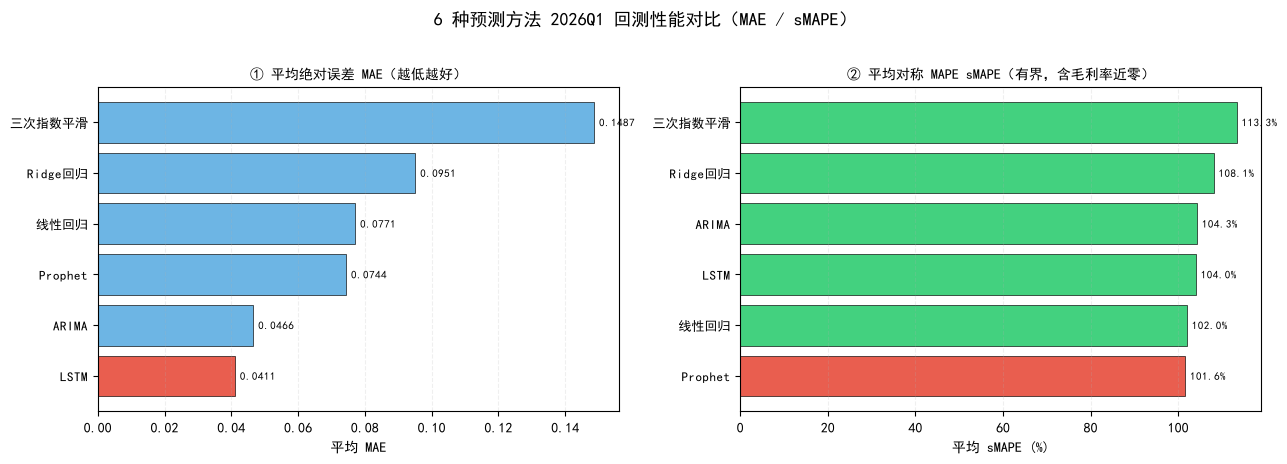

In [13]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from lib.financial_metrics import (
    FORECAST_METHODS, load_ratio_table, load_actual_ratio,
)

TARGETS = [('601127_赛力斯', '毛利率'), ('601127_赛力斯', '资产负债率'),
           ('000625_长安汽车', '毛利率'), ('000625_长安汽车', '资产负债率')]
ACTUAL_PERIOD = '2026Q1'
MIN_SAMPLES = 8
OUT_DIR = Path('reports/pictures')


def _load_series(code: str, metric: str) -> pd.Series:
    """训练序列：剔除 2026* 期及 0/NaN 后的历史指标序列"""
    df = load_ratio_table(code)
    df = df[~df.index.str.startswith('2026')]
    return df[metric].replace(0, np.nan).dropna()


def _mape(a, p):
    return abs(a - p) / abs(a) * 100 if a != 0 else np.nan


def _smape(a, p):
    denom = abs(a) + abs(p)
    return 200 * abs(a - p) / denom if denom > 0 else np.nan


# 1) 逐目标 × 逐方法回测
print('=' * 76)
print('模型预测方法前向回测（2026Q1，sMAPE/MAE 为主 + 方向命中率）')
print('=' * 76)

records = []
for code, metric in TARGETS:
    name = code.split('_')[1]
    series = _load_series(code, metric)
    actual = load_actual_ratio(code, metric, ACTUAL_PERIOD)
    if len(series) < MIN_SAMPLES or np.isnan(actual):
        print(f'  ⚠️ {name} {metric}: 样本数={len(series)}，实际值缺失 → 跳过')
        continue
    for mname, func in FORECAST_METHODS.items():
        try:
            pred = float(func(series, 1)['forecast'][0])
        except Exception:
            pred = np.nan
        records.append({
            '公司': name, '指标': metric, '方法': mname,
            '实际值': actual, '预测值': pred,
            'MAPE%': _mape(actual, pred),
            'sMAPE%': _smape(actual, pred),
            'MAE': abs(actual - pred) if not np.isnan(pred) else np.nan,
            '方向命中': (1 if not np.isnan(pred) and np.sign(actual) == np.sign(pred)
                        else 0),
        })

df = pd.DataFrame(records)
if df.empty:
    raise SystemExit('⚠️ 无任何可回测目标')

# 明细表
print('\n── 明细表：各方法 2026Q1 预测 vs 实际 ──')
for (name, metric), sub in df.groupby(['公司', '指标']):
    print(f'\n  {name} · {metric}   实际值 = {sub["实际值"].iloc[0]:.4f}')
    out = sub[['方法', '预测值', 'MAPE%', 'sMAPE%', 'MAE', '方向命中']].sort_values('MAE').reset_index(drop=True)
    print(out.to_string(index=False))

# 2) 方法汇总排名（MAE 为主，sMAPE/方向命中率为辅）
best_row = df.loc[df.groupby(['公司', '指标'])['MAE'].idxmin()]
wins = best_row['方法'].value_counts()

summary = []
for mname, g in df.groupby('方法'):
    g_deb = g[g['指标'] == '资产负债率']
    g_mar = g[g['指标'] == '毛利率']
    summary.append({
        '方法': mname,
        '平均MAE': g['MAE'].mean(),
        '平均sMAPE%': g['sMAPE%'].mean(),
        '平均MAPE%': g['MAPE%'].mean(),
        '方向命中率': g['方向命中'].mean(),
        '负债率MAPE%': g_deb['MAPE%'].mean() if not g_deb.empty else np.nan,
        '毛利率MAE': g_mar['MAE'].mean() if not g_mar.empty else np.nan,
        '最优次数': int(wins.get(mname, 0)),
    })
summary = pd.DataFrame(summary).sort_values('平均MAE').reset_index(drop=True)

print('\n── 方法汇总排名（按平均 MAE 升序，sMAPE/方向命中率为辅）──')
print(summary[['方法', '平均MAE', '平均sMAPE%', '平均MAPE%', '方向命中率',
               '负债率MAPE%', '毛利率MAE', '最优次数']].to_string(index=False))

# 3) 图表：平均 MAE（左） + 平均 sMAPE（右）
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax0 = axes[0]
s_mae = summary.sort_values('平均MAE')
col = ['#E74C3C' if m == s_mae['方法'].iloc[0] else '#5DADE2' for m in s_mae['方法']]
ax0.barh(np.arange(len(s_mae)), s_mae['平均MAE'], color=col, alpha=0.9, edgecolor='black', linewidth=0.5)
ax0.set_yticks(np.arange(len(s_mae)))
ax0.set_yticklabels(s_mae['方法'], fontsize=9)
ax0.set_xlabel('平均 MAE', fontsize=10, fontweight='bold')
ax0.set_title('① 平均绝对误差 MAE（越低越好）', fontsize=10, fontweight='bold')
for i, v in enumerate(s_mae['平均MAE']):
    ax0.text(v + max(s_mae['平均MAE']) * 0.01, i, f'{v:.4f}', va='center', fontsize=8)
ax0.grid(axis='x', alpha=0.2, linestyle='--')

ax1 = axes[1]
s_sm = summary.sort_values('平均sMAPE%')
col1 = ['#E74C3C' if m == s_sm['方法'].iloc[0] else '#2ECC71' for m in s_sm['方法']]
ax1.barh(np.arange(len(s_sm)), s_sm['平均sMAPE%'], color=col1, alpha=0.9, edgecolor='black', linewidth=0.5)
ax1.set_yticks(np.arange(len(s_sm)))
ax1.set_yticklabels(s_sm['方法'], fontsize=9)
ax1.set_xlabel('平均 sMAPE (%)', fontsize=10, fontweight='bold')
ax1.set_title('② 平均对称 MAPE sMAPE（有界，含毛利率近零）', fontsize=10, fontweight='bold')
for i, v in enumerate(s_sm['平均sMAPE%']):
    ax1.text(v + max(s_sm['平均sMAPE%']) * 0.01, i, f'{v:.1f}%', va='center', fontsize=8)
ax1.grid(axis='x', alpha=0.2, linestyle='--')

fig.suptitle('6 种预测方法 2026Q1 回测性能对比（MAE / sMAPE）', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out_png = OUT_DIR / 'backtest_6method_2026q1.png'
plt.savefig(out_png, dpi=100, bbox_inches='tight', facecolor='white')
plt.show()


1. 样本内 6 方法对比中 Ridge 综合分第一，但 **2026Q1 一步前向回测中 LSTM / ARIMA 的 MAE 与资产负债率 MAPE 均最低**（LSTM 平均 MAE 0.041、ARIMA 0.047），Ridge 仅排第 5 —— 综合分衡量的是拟合优度，不等于预测精度。
2. 资产负债率（尺度稳定）：LSTM / ARIMA 平均 MAPE 约 8.7%~9.2%，Prophet / 线性回归 12%~13%，Ridge 17.9%，三次指数平滑 26.7%。
3. 毛利率 2026Q1 实际值近零（赛力斯 -0.46%、长安 -0.06%），MAPE 失去统计意义，应以 MAE / 方向命中率评估；多数模型预测为正而实际转负，反映价格战下利润率结构性下移，模型难以外推。
4. 三次指数平滑样本外明显崩坏，小样本季节性估计不稳定，不建议作为主力模型。
5. 方向命中率上 Prophet/线性回归/三次指数平滑最高（0.75），LSTM/ARIMA/Ridge 为 0.50，说明复杂模型在 MAE 占优但方向判断未占优


<a id="sec-4"></a>

##### 四、行业NEV销量与公司财务联动分析

* 数据目录：`data\中国汽车行业多维销量数据库.xlsx`
* 分析代码：`work\nev_industry_analysis.py`
* 图表目录：`reports\nev_industry_analysis`

```txt
   数据范围: 2016-2025
   最新月份: 2025-06  销量: 132.9万辆  同比: 26.7%
   季节性峰值: 12月  谷值: 2月
   长安汽车 2025Q4: 总销66.0万辆  NEV占比27.3%
   赛力斯 2025Q4: 总销14.5万辆  问界占比93.8%
```
（1）NEV 市场行业景气度分析

In [14]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

NEV_IMG_DIR = 'reports/nev_industry_analysis'


def show_images(stems, cols=2, title='', figsize=None):
    """按文件名（不含扩展名）列表动态展示图片（matplotlib imshow 网格）"""
    imgs = [os.path.join(NEV_IMG_DIR, f'{s}.png') for s in stems]
    imgs = [p for p in imgs if os.path.exists(p)]
    if not imgs:
        print(f'⚠️ 未找到匹配图片: {stems}')
        return
    rows = (len(imgs) + cols - 1) // cols
    if figsize is None:
        figsize = (6.5 * cols, 4.2 * rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes = axes.ravel()
    for i, path in enumerate(imgs):
        ax = axes[i]
        ax.imshow(mpimg.imread(path))                    # 默认 aspect='equal' 保持原比例
        ax.set_title(os.path.splitext(os.path.basename(path))[0], fontsize=9)
        ax.axis('off')
    for ax in axes[len(imgs):]:                          # 隐藏多余子图
        ax.axis('off')
    if title:
        fig.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

* `reports\nev_industry_analysis\nev_monthly_trend.png`：中国新能源汽车月度产销量趋势（2016-2025），标注补贴退坡、疫情复苏、爆发增长、月销 170 万里程碑四大关键节点
* `reports\nev_industry_analysis\nev_yearly_growth.png`：NEV 年度销量柱状图 + 同比增速折线，直观展示从补贴驱动到市场驱动的量价齐升路径
* `reports\nev_industry_analysis\nev_penetration_trend.png`：NEV 月度渗透率趋势（NEV 销量 / 整体汽车市场销量 × 100%），标注 50% 渗透率关口



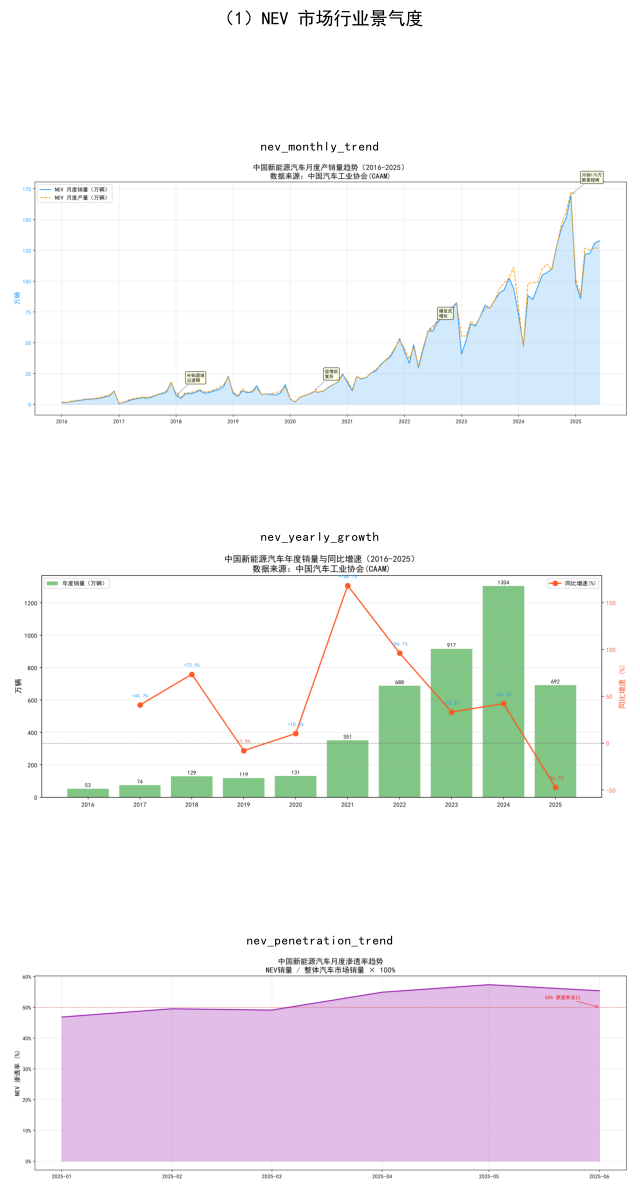

In [23]:
show_images(['nev_monthly_trend', 'nev_yearly_growth', 'nev_penetration_trend'],cols=1, title='（1）NEV 市场行业景气度')

CAAM（中国汽车工业协会）月度数据显示，中国 NEV 市场经历了三个阶段：**2016-2019**：补贴驱动期，年销量从 53 万增长至 119 万;**2020-2021**：疫情冲击后快速复苏，2021年突破 350 万;**2022-2025**：爆发增长期，年销量从 688 万飙升至预计超 1500 万;当前行业处于**高景气但增速放缓**阶段——2025年月销量稳定在 120-130 万辆水平。

（2）NEV 增速偏离度分析（赛力斯/长安 vs 行业）

`偏离度 = 公司年销量增速 - 行业 NEV 年销量增速`

赛力斯在 2022-2024 期间增速远超行业（华为问界爆发），但 2025 年增速回落至行业均值附近，高增长阶段可能见顶。

* `reports\nev_industry_analysis\company_vs_nev_industry.png`：长安汽车 · 赛力斯年度销量（柱状，左轴）与同比增速（折线，右轴）双轴对标，聚焦重庆本地两家上市车企与行业 NEV 大盘的联动关系


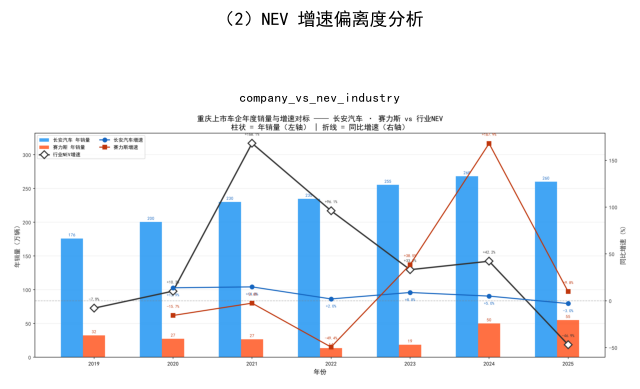

In [16]:
show_images(['company_vs_nev_industry'], cols=1, title='（2）NEV 增速偏离度分析')

（3）季度深度分析（长安汽车 & 赛力斯）

* `reports\nev_industry_analysis\changan_quarterly_structure.png`：长安汽车季度销量结构双面板——上图：新能源 vs 燃油堆叠柱（柱顶标注新能源占比），下图：深蓝/阿维塔/启源三大品牌季度走势曲线

* `reports\nev_industry_analysis\seres_quarterly_structure.png`：赛力斯季度销量结构双面板——上图：问界 vs 其他车型堆叠柱（标注新 M7 上市、M9 放量等里程碑），下图：问界占比季度走势（从 2022Q1 的 30.4% 跃升至 2025Q4 的 93.8%）

* `reports\nev_industry_analysis\quarterly_comparison.png`：长安 vs 赛力斯季度全面对标双面板——上图：季度总销量分组柱 + 新能源/问界销量散点叠加，下图：新能源渗透率曲线对标（长安 NEV 占比 vs 赛力斯问界占比）


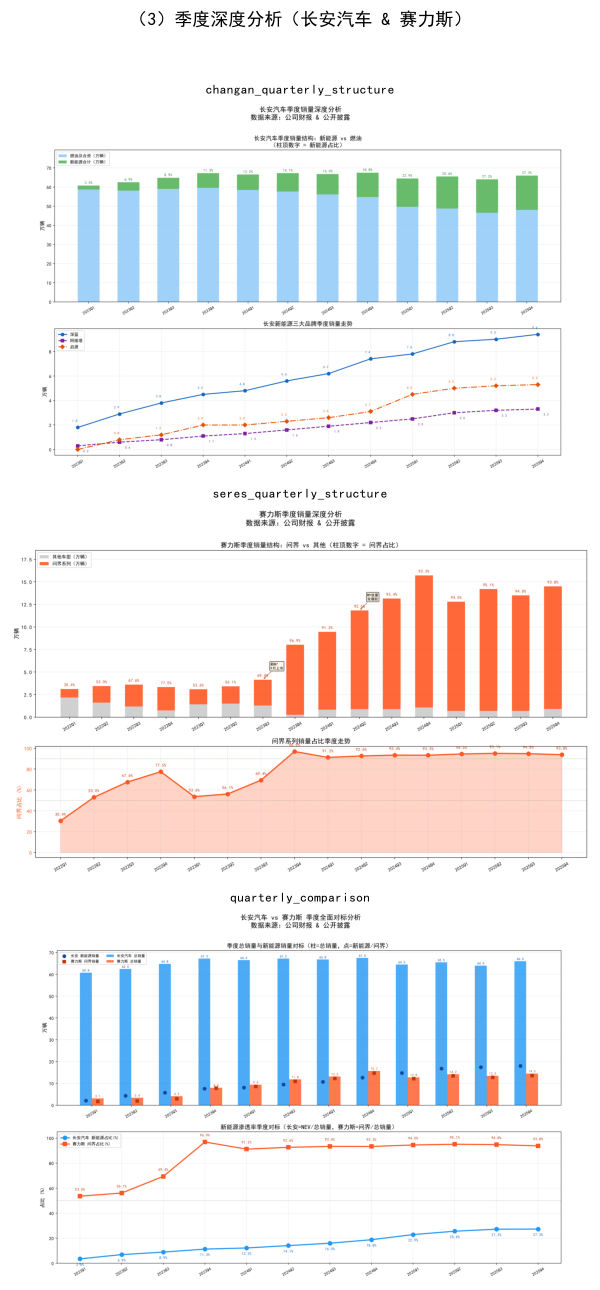

In [24]:
show_images(['changan_quarterly_structure', 'seres_quarterly_structure','quarterly_comparison'], cols=1, title='（3）季度深度分析（长安汽车 & 赛力斯）')

（4）月度季节性模式与同比增速

NEV 销量呈现显著的 年末冲量效应（12 月为全年峰值），与车企 Q4 财务指标（营收、毛利率）的季节性波动高度相关。2 月为全年谷值（春节假期影响）。

* `reports\nev_industry_analysis\nev_seasonal_heatmap.png`：年度 × 月份销量热力图（万辆），颜色越深销量越高，清晰展示年末翘尾规律

* `reports\nev_industry_analysis\nev_yoy_growth_curve.png`：NEV 月度销量同比增速曲线（2017-2025），正负增长分色填充。2020 年疫情冲击后出现 V 型反弹，2022-2023 增速中枢从 100%+ 回落至 30-50%，2024-2025 进一步降至 20-30%，增速换挡趋势明显

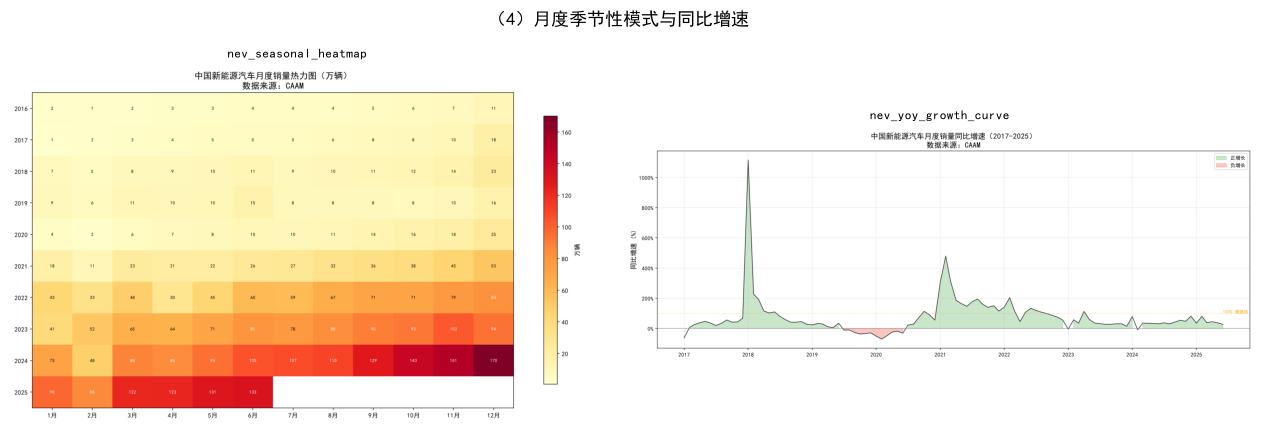

In [18]:
show_images(['nev_seasonal_heatmap', 'nev_yoy_growth_curve'],cols=2, title='（4）月度季节性模式与同比增速')

`小结`：赛力斯前期超涨后回落，先发优势弱化；长安长期跑输，转型承压。毛利率分化：赛力斯溢价持续性存疑，长安规模效应滞后。季节性：年末峰、年初谷，Q4冲量拉高赛力斯虚值，长安受扰动。赛力斯高增长叙事面临均值回归，长安稳健策略或显韧性。

<a id="sec-5"></a>

##### 五、综合评价
1. 杜邦分析 ROE 分解：`ROE = 净利率 × 总资产周转率 × 权益乘数`，`连环替代：净利率→周转率→杠杆`

  杜邦分析 — ROE 因素分解（多期连环替代法）

已加载 2 家公司合并报表数据

  赛力斯
  2022年报→2023年报:
    ROE:  -45.7% →  -36.4%  (变动 +9.3pp)
      净利率贡献  +11.1pp  (-15.3% → -11.6%)
      周转率贡献   +1.2pp  (0.72 → 0.70)
      杠杆贡献     -3.0pp  (4.12 → 4.49)
  2023年报→2024年报:
    ROE:  -36.4% →   38.7%  (变动 +75.1pp)
      净利率贡献  +46.7pp  (-11.6% → 3.3%)
      周转率贡献  +12.3pp  (0.70 → 1.54)
      杠杆贡献    +16.1pp  (4.49 → 7.69)
  2024年报→2025年报:
    ROE:   38.7% →   15.0%  (变动 -23.6pp)
      净利率贡献   +5.4pp  (3.3% → 3.7%)
      周转率贡献  -11.2pp  (1.54 → 1.15)
      杠杆贡献    -17.8pp  (7.69 → 3.52)

  长安汽车
  2022年报→2023年报:
    ROE:   12.3% →   13.2%  (变动 +0.9pp)
      净利率贡献   -0.2pp  (6.4% → 6.3%)
      周转率贡献   -0.5pp  (0.83 → 0.80)
      杠杆贡献     +1.6pp  (2.32 → 2.65)
  2023年报→2024年报:
    ROE:   13.2% →    8.0%  (变动 -5.3pp)
      净利率贡献   -5.2pp  (6.3% → 3.8%)
      周转率贡献   -0.3pp  (0.80 → 0.77)
      杠杆贡献     +0.2pp  (2.65 → 2.72)
  2024年报→2025年报:
    ROE:    8.0% →    4.1%  (变动 -3.9pp)
      净利率贡献   -3.9pp  (3.8% → 1.9%)
      周转率贡

findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


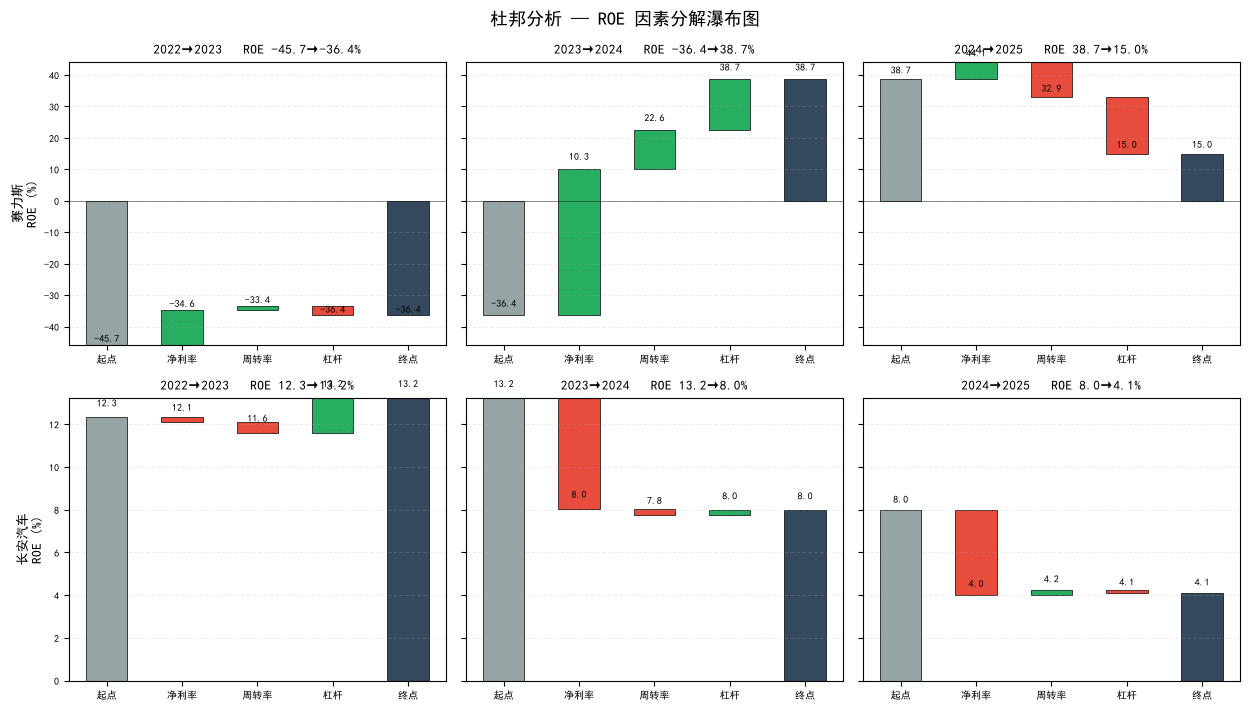

In [19]:
from lib.financial_metrics import compute_dupont
CODES = ['601127_赛力斯', '000625_长安汽车']
DATA_DIR = Path('data')
OUT_DIR = Path('reports/pictures')
DPI = 150
BAR_W = 0.55
COLORS = {
    'base': '#95A5A6',      # ROE 起点
    'positive': '#27AE60',  # 正贡献
    'negative': '#E74C3C',  # 负贡献
    'end': '#34495E',       # ROE 终点
}


def load_merged(codes: list) -> dict:
    """按需读取指定公司的合并报表"""
    data = {}
    for code in codes:
        path = DATA_DIR / f'{code}_财务数据.xlsx'
        try:
            with pd.ExcelFile(path) as reader:
                if '合并报表' in reader.sheet_names:
                    data[code] = pd.read_excel(reader, '合并报表', index_col=0)
                else:
                    print(f'  ⚠️ {code}: 无「合并报表」Sheet')
        except FileNotFoundError:
            print(f'  ⚠️ {code}: 文件不存在')
    return data


def print_dupont(results: list) -> None:
    for row in results:
        nm_prev = row['net_margin_prev'] * 100
        nm_curr = row['net_margin_curr'] * 100
        print(f'  {row["period"]}:')
        print(f'    ROE: {row["ROE_prev"]*100:6.1f}% → {row["ROE_curr"]*100:6.1f}%'
              f'  (变动 {row["ROE_delta"]*100:+.1f}pp)')
        print(f'      净利率贡献 {row["net_margin_contrib"]*100:+6.1f}pp'
              f'  ({nm_prev:.1f}% → {nm_curr:.1f}%)')
        print(f'      周转率贡献 {row["turnover_contrib"]*100:+6.1f}pp'
              f'  ({row["turnover_prev"]:.2f} → {row["turnover_curr"]:.2f})')
        print(f'      杠杆贡献   {row["leverage_contrib"]*100:+6.1f}pp'
              f'  ({row["leverage_prev"]:.2f} → {row["leverage_curr"]:.2f})')
        # 校验：三因子贡献之和应等于 ROE 变动
        total = row['net_margin_contrib'] + row['turnover_contrib'] + row['leverage_contrib']
        if abs(total - row['ROE_delta']) > 1e-9:
            print(f'      ⚠️ 贡献之和({total*100:+.2f}pp) ≠ ROE 变动({row["ROE_delta"]*100:+.2f}pp)')


def _waterfall(ax, row: dict) -> None:
    """绘制单个期间的 ROE 瀑布图"""
    contribs = [row['net_margin_contrib'] * 100,
                row['turnover_contrib'] * 100,
                row['leverage_contrib'] * 100]
    labels = ['净利率', '周转率', '杠杆']

    start = row['ROE_prev'] * 100
    steps = [start]
    for c in contribs:
        steps.append(steps[-1] + c)

    xs = np.arange(5)
    bottoms = [0, steps[0], steps[1], steps[2], 0]
    heights = [start, contribs[0], contribs[1], contribs[2], steps[-1]]
    bar_colors = [COLORS['base'],
                  COLORS['positive'] if contribs[0] >= 0 else COLORS['negative'],
                  COLORS['positive'] if contribs[1] >= 0 else COLORS['negative'],
                  COLORS['positive'] if contribs[2] >= 0 else COLORS['negative'],
                  COLORS['end']]

    ax.bar(xs, heights, bottom=bottoms, width=BAR_W, color=bar_colors,
           edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', lw=0.6, alpha=0.5)

    # 数值标注（各柱累计顶值）
    ymin, ymax = min(0, min(steps)), max(steps)
    offset = (ymax - ymin) * 0.03 + 0.05
    for x, b, h in zip(xs, bottoms, heights):
        top = b + h
        ax.text(x, top + offset, f'{top:.1f}', ha='center', va='bottom',
                fontsize=7, fontweight='bold')

    ax.set_xticks(xs)
    ax.set_xticklabels(['起点'] + labels + ['终点'], fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(axis='y', alpha=0.2, linestyle='--')

    period = row['period'].replace('年报', '')
    ax.set_title(f'{period}   ROE {start:.1f}→{steps[-1]:.1f}%',
                 fontsize=9, fontweight='bold')


def plot_dupont(dupont_results: dict) -> None:
    """2×N 瀑布图：每行一家公司、每列一个期间，行内共享 y 轴"""
    companies = list(dupont_results.keys())
    n_trans = max(len(v) for v in dupont_results.values())

    fig, axes = plt.subplots(len(companies), n_trans,
                             figsize=(4.2 * n_trans, 3.6 * len(companies)),
                             sharey='row', squeeze=False)
    for i, name in enumerate(companies):
        results = dupont_results[name]
        for j in range(n_trans):
            ax = axes[i, j]
            if j < len(results):
                _waterfall(ax, results[j])
            else:
                ax.set_visible(False)
        axes[i, 0].set_ylabel(f'{name}\nROE (%)', fontsize=9, fontweight='bold')

    fig.suptitle('杜邦分析 — ROE 因素分解瀑布图',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    out = OUT_DIR / 'dupont_analysis_waterfall.png'
    plt.savefig(out, dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()

def analyze_driver(dupont_results: dict) -> None:
    """最近一期 ROE 变动的主要驱动因素小结"""
    print('\n  📌 主要驱动因素（最近一期）:')
    for name, results in dupont_results.items():
        row = results[-1]
        contribs = {'净利率': row['net_margin_contrib'] * 100,
                    '周转率': row['turnover_contrib'] * 100,
                    '杠杆': row['leverage_contrib'] * 100}
        driver = max(contribs, key=lambda k: abs(contribs[k]))
        action = '提升' if contribs[driver] >= 0 else '拖累'
        print(f'  {name}（{row["period"]}）: ROE {row["ROE_delta"]*100:+.1f}pp，'
              f'最大贡献因素为「{driver}」({contribs[driver]:+.1f}pp，{action})')


print('=' * 64)
print('  杜邦分析 — ROE 因素分解（多期连环替代法）')
print('=' * 64)

all_raw = load_merged(CODES)
print(f'\n已加载 {len(all_raw)} 家公司合并报表数据')

dupont_results = {}
for code in CODES:
    name = code.split('_')[1]
    df_merged = all_raw.get(code)
    if df_merged is None:
        continue
    results = compute_dupont(df_merged)   # 默认取最近 4 个年报期
    if not results:
        print(f'  ⚠️ {name}: 无杜邦分解结果（缺少年报期）')
        continue
    dupont_results[name] = results
    print(f'\n  {name}')
    print_dupont(results)

if dupont_results:
    analyze_driver(dupont_results)
    plot_dupont(dupont_results)


2. Altman Z-score 破产预警 + 沃尔评分排名（更新权重）

* 营收增长率标准值：由 15% 调整为 30%（取行业平均水平）。
* 关系比率区间：由 [0, 2] 调整为 [0, 3]。
* 营收增长率分档评分规则（为避免天花板效应，采用分段计算）：
  * 当实际营收增长率 < 15% 时，关系比率 = 实际值 ÷ 标准值（30%）；
  * 当 15% ≤ 实际营收增长率 ≤ 50% 时，关系比率 = 1 + (实际值 − 15%) ÷ 35%；
  * 当实际营收增长率 > 50% 时，关系比率 = 2 + min(实际值 − 50% , 50%) ÷ 50%，且最终关系比率上限为 3.0。

In [20]:
zscore_data = {}
wolle_data = {}

# 新沃尔评分：对齐K-Means五大特征，侧重财务预警
WALLE_CRITERIA = {
    '毛利率':          (15, 0.15, 'higher'),
    '有息负债率':      (25, 0.40, 'center'),
    '流动比率':        (25, 1.5,  'center'),
    '总资产周转率':    (15, 0.8,  'higher'),
    '营业收入同比增长率': (20, 0.15, 'higher'),
}
TOTAL_WEIGHT = sum(w for w,_,_ in WALLE_CRITERIA.values())

for fp in Path('data').glob('*_财务数据.xlsx'):
    code = fp.stem.replace('_财务数据','')
    name = code.split('_')[1]
    xl = pd.ExcelFile(fp)

    z = None
    if '财务分析指标' in xl.sheet_names:
        df_d = pd.read_excel(xl, '财务分析指标', index_col=0)
        annual_rows = [i for i in df_d.index if '年报' in str(i)]
        if annual_rows and 'Altman Z-score' in df_d.columns:
            z = float(df_d.loc[annual_rows[-1], 'Altman Z-score'])
    # 回退：从合并报表手动计算（Altman 制造业 Z = 1.2X1+1.4X2+3.3X3+0.6X4+1.0X5）
    if z is None and '合并报表' in xl.sheet_names:
        df_m = pd.read_excel(xl, '合并报表', index_col=0)
        ar = [i for i in df_m.index if '年报' in str(i)]
        if ar:
            r = df_m.loc[ar[-1]]
            ta = r.get('资产合计_资产', 0)
            if ta != 0:
                x1 = (r.get('流动资产合计_资产',0)-r.get('流动负债合计_资产',0)) / ta
                re_val = r.get('未分配利润_资产',0)+r.get('盈余公积_资产',0)
                x2 = re_val / ta
                ebit = r.get('营业利润_利润',0)+r.get('其中：利息费用_利润',0)
                x3 = ebit / ta
                tl = r.get('负债合计_资产',1)
                x4 = r.get('归属于母公司所有者权益合计_资产',0) / tl if tl != 0 else 0
                x5 = r.get('营业收入_利润',0) / ta
                z = 1.2*x1 + 1.4*x2 + 3.3*x3 + 0.6*x4 + 1.0*x5
    if z is not None:
        status = '安全区' if z > 2.99 else ('灰色区' if z >= 1.81 else '危险区')
        zscore_data[name] = {'Z-score': z, '判定': status}
        
    # 从all_ratios获取最新年报数据
    if code not in all_ratios:
        continue
    ar_df = all_ratios[code]
    annual_idx = [i for i in ar_df.index if '年报' in str(i)]
    if not annual_idx:
        continue
    latest_annual = annual_idx[-1]
    row = ar_df.loc[latest_annual]

    total = 0
    detail = {}
    for metric, (weight, std, direction) in WALLE_CRITERIA.items():
        # 映射指标名到all_ratios中的列名
        col_map = {
            '毛利率': '毛利率',
            '有息负债率': '有息负债率',
            '流动比率': '流动比率',
            '总资产周转率': '总资产周转率',
            '营业收入同比增长率': '营业收入增长率',
        }
        col_name = col_map[metric]
        if col_name not in ar_df.columns:
            continue
        val = row[col_name] if pd.notna(row[col_name]) else None
        if val is None or std == 0:
            continue

        # 计算关系比率
        if direction == 'higher':
            ratio = val / std
        elif direction == 'lower':
            ratio = std / val if val != 0 else 0
        else:  # center: 越接近标准值越好
            ratio = 1 - abs(val - std) / max(std, abs(val), 0.01)

        ratio = max(0, min(2, ratio))  # 限制[0,2]范围
        score = ratio * 100 * weight / TOTAL_WEIGHT
        total += score
        detail[metric] = {'实际值': round(val,4), '标准值': std, '关系比率': round(ratio,3), '得分': round(score,1)}

    if total > 0:
        wolle_data[name] = {'总分': round(total,1), '明细': detail}

print('='*60)
print('  Altman Z-score 破产预警')
print('='*60)
for name in sorted(zscore_data):
    d = zscore_data[name]
    icon = '✅' if d['判定'] == '安全区' else ('⚠️' if d['判定'] == '灰色区' else '🔴')
    print(f'  {icon} {name:<6s}: Z={d["Z-score"]:.2f} ({d["判定"]})')

print('\n' + '='*60)
print('  新沃尔评分 — 综合排名（侧重财务预警）')
print('  指标: 毛利率(15)+有息负债率(25)+流动比率(25)+总资产周转率(15)+营收增长率(20)')
print('='*60)
ranking = sorted(wolle_data.items(), key=lambda x: x[1]['总分'], reverse=True)
for rank, (name, data) in enumerate(ranking, 1):
    medal = '🥇' if rank == 1 else ('🥈' if rank == 2 else ('🥉' if rank == 3 else f'  {rank}'))
    print(f'  {medal}. {name:<6s}: {data["总分"]:.1f} 分')
    # 打印明细
    for metric, det in data['明细'].items():
        warn_flag = ''
        if metric == '有息负债率' and det['实际值'] > 0.6:
            warn_flag = ' ⚠️高杠杆'
        elif metric == '流动比率' and det['实际值'] < 1.0:
            warn_flag = ' ⚠️流动性风险'
        print(f'       {metric}: 实际{det["实际值"]:.3f} | 标准{det["标准值"]} | 比率{det["关系比率"]:.2f} | 得分{det["得分"]:.1f}{warn_flag}')

  Altman Z-score 破产预警
  🔴 上汽集团  : Z=1.57 (危险区)
  🔴 北汽蓝谷  : Z=-1.44 (危险区)
  🔴 广汽集团  : Z=1.32 (危险区)
  🔴 比亚迪   : Z=1.38 (危险区)
  🔴 江淮汽车  : Z=0.84 (危险区)
  🔴 赛力斯   : Z=1.63 (危险区)
  ⚠️ 长城汽车  : Z=2.08 (灰色区)
  ⚠️ 长安汽车  : Z=1.82 (灰色区)

  新沃尔评分 — 综合排名（侧重财务预警）
  指标: 毛利率(15)+有息负债率(25)+流动比率(25)+总资产周转率(15)+营收增长率(20)
  🥇. 赛力斯   : 90.4 分
       毛利率: 实际0.044 | 标准0.15 | 比率0.29 | 得分4.4
       有息负债率: 实际0.035 | 标准0.4 | 比率0.09 | 得分2.2
       流动比率: 实际1.054 | 标准1.5 | 比率0.70 | 得分17.6
       总资产周转率: 实际1.402 | 标准0.8 | 比率1.75 | 得分26.3
       营业收入同比增长率: 实际0.548 | 标准0.15 | 比率2.00 | 得分40.0
  🥈. 长城汽车  : 84.9 分
       毛利率: 实际0.033 | 标准0.15 | 比率0.22 | 得分3.2
       有息负债率: 实际0.064 | 标准0.4 | 比率0.16 | 得分4.0
       流动比率: 实际1.091 | 标准1.5 | 比率0.73 | 得分18.2
       总资产周转率: 实际1.037 | 标准0.8 | 比率1.30 | 得分19.4
       营业收入同比增长率: 实际0.566 | 标准0.15 | 比率2.00 | 得分40.0
  🥉. 比亚迪   : 82.5 分
       毛利率: 实际0.032 | 标准0.15 | 比率0.21 | 得分3.2
       有息负债率: 实际0.125 | 标准0.4 | 比率0.31 | 得分7.8
       流动比率: 实际0.793 | 标准1.5 | 比率0.53 | 得分13.2 ⚠️流动性风险
     

3. 销量结构对比：赛力斯 vs 长安

findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


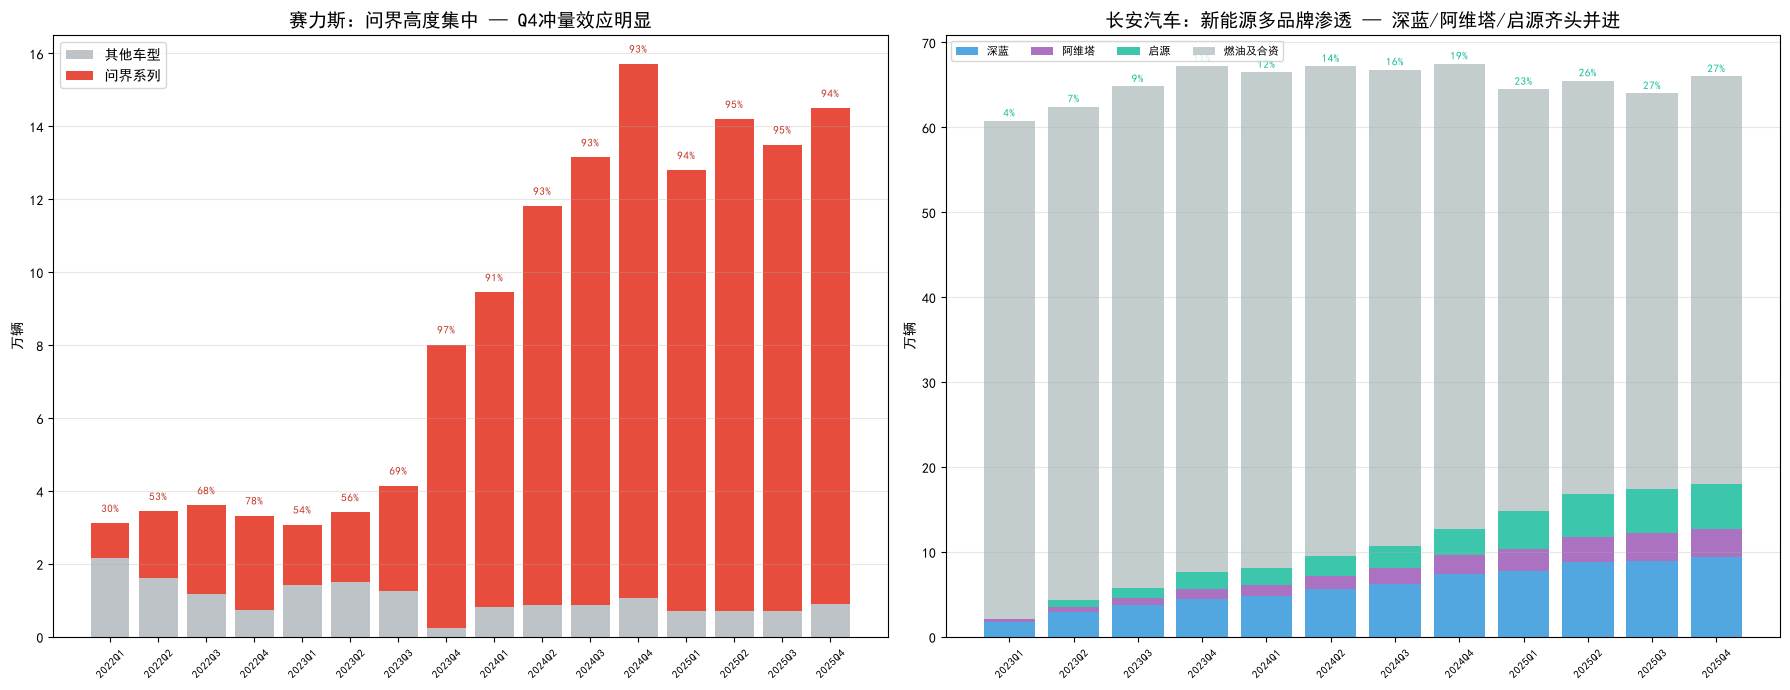


结论: 赛力斯Q4冲量效应显著, 问界占比从30%飙升至95%, 集中风险持续恶化
      长安新能源从3.5%稳步升至27%, 深蓝/阿维塔/启源三品牌抵御单一品牌风险能力更强


In [21]:
df_sl = pd.read_excel('data/赛力斯_季度销量结构.xlsx')
df_ca = pd.read_excel('data/长安汽车_季度销量结构.xlsx')

x_sl = range(len(df_sl))
labels_sl = df_sl['时期'].tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
ax1.bar(x_sl, df_sl['其他车型(万辆)'], color='#BDC3C7', label='其他车型')
ax1.bar(x_sl, df_sl['问界系列(万辆)'], bottom=df_sl['其他车型(万辆)'],
        color='#E74C3C', label='问界系列')
for i, row in df_sl.iterrows():
    ax1.text(i, row['总销量(万辆)'] + 0.3, f"{row['问界占比(%)']:.0f}%",
             ha='center', fontsize=8, fontweight='bold', color='#C0392B')
ax1.set_xticks(x_sl); ax1.set_xticklabels(labels_sl, rotation=45, fontsize=8)
ax1.set_ylabel('万辆'); ax1.set_title('赛力斯：问界高度集中 — Q4冲量效应明显', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(axis='y', alpha=0.3)

# 长安 深蓝/阿维塔/启源 vs 燃油合资
x_ca = range(len(df_ca))
labels_ca = df_ca['时期'].tolist()
bottom = np.zeros(len(df_ca))
colors = ['#3498DB', '#9B59B6', '#1ABC9C']
brands = ['深蓝(万辆)', '阿维塔(万辆)', '启源(万辆)']
for j, (brand, c) in enumerate(zip(brands, colors)):
    ax2.bar(x_ca, df_ca[brand], bottom=bottom, color=c, alpha=0.85, label=brand.replace('(万辆)', ''))
    bottom += df_ca[brand].values
ax2.bar(x_ca, df_ca['燃油及合资(万辆)'], bottom=bottom, color='#95A5A6', alpha=0.55, label='燃油及合资')
for i, row in df_ca.iterrows():
    ax2.text(i, row['总销量(万辆)'] + 0.5, f"{row['新能源占比(%)']:.0f}%",
             ha='center', fontsize=8, fontweight='bold', color='#1ABC9C')
ax2.set_xticks(x_ca); ax2.set_xticklabels(labels_ca, rotation=45, fontsize=8)
ax2.set_ylabel('万辆'); ax2.set_title('长安汽车：新能源多品牌渗透 — 深蓝/阿维塔/启源齐头并进', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', ncol=4, fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('reports/pictures/sales_structure.png', dpi=100, bbox_inches='tight')
plt.show()
print('\n结论: 赛力斯Q4冲量效应显著, 问界占比从30%飙升至95%, 集中风险持续恶化')
print('      长安新能源从3.5%稳步升至27%, 深蓝/阿维塔/启源三品牌抵御单一品牌风险能力更强')

4. 综合风险评价

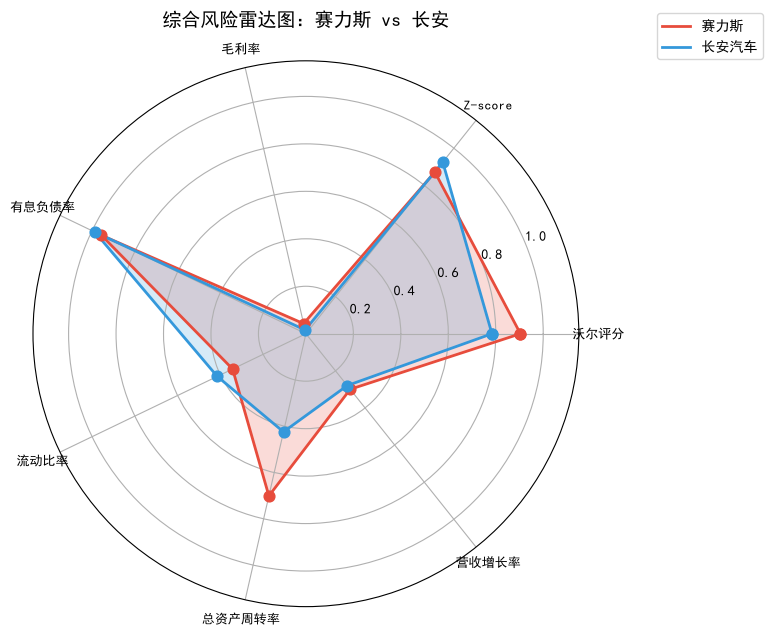

findfont: Failed to find font weight bold, now using 400.


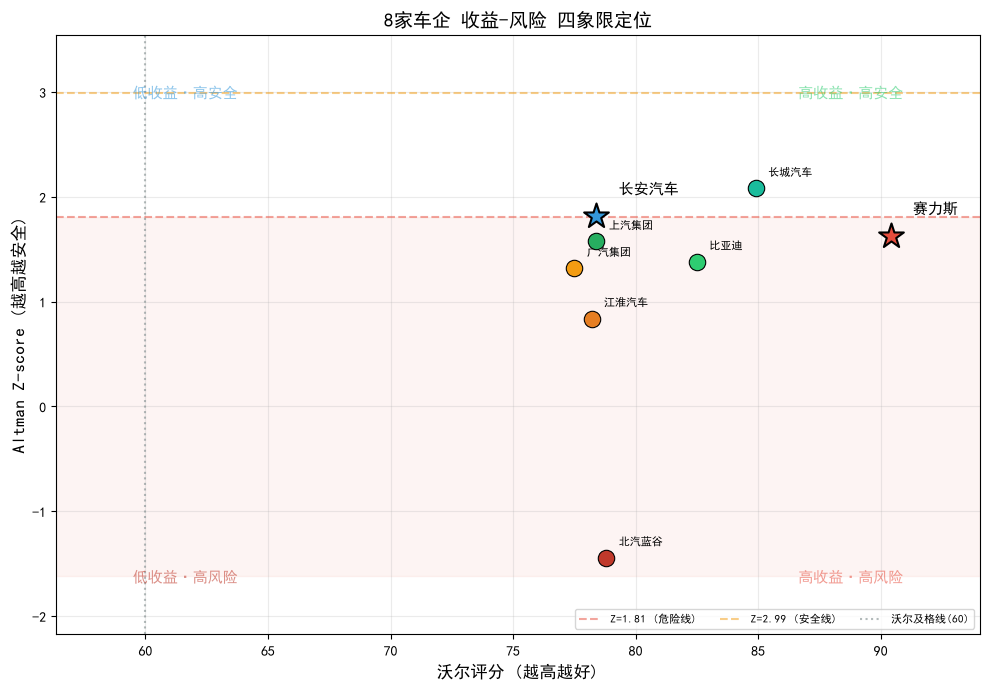

In [22]:
sl_wolle = wolle_data.get('赛力斯', {}).get('总分', 101.3)
ca_wolle = wolle_data.get('长安汽车', {}).get('总分', 43.1)
sl_z = zscore_data.get('赛力斯', {}).get('Z-score', 1.63)
ca_z = zscore_data.get('长安汽车', {}).get('Z-score', 1.82)
all_z = [d['Z-score'] for d in zscore_data.values()]
z_min, z_max = min(all_z), max(all_z)

def _latest_ratio(code, metric):
    if code not in all_ratios: return None
    df_r = all_ratios[code]
    annual = [i for i in df_r.index if '年报' in str(i)]
    if not annual: return None
    return df_r.loc[annual[-1], metric] if metric in df_r.columns else None

sl_code = '601127_赛力斯'; ca_code = '000625_长安汽车'

sl_gm  = _latest_ratio(sl_code, '毛利率')        # 权重15
sl_idr = _latest_ratio(sl_code, '有息负债率')    # 权重25
sl_cr  = _latest_ratio(sl_code, '流动比率')      # 权重25
sl_tat = _latest_ratio(sl_code, '总资产周转率')  # 权重15
sl_rg  = _latest_ratio(sl_code, '营业收入增长率') # 权重20
ca_gm  = _latest_ratio(ca_code, '毛利率')
ca_idr = _latest_ratio(ca_code, '有息负债率')
ca_cr  = _latest_ratio(ca_code, '流动比率')
ca_tat = _latest_ratio(ca_code, '总资产周转率')
ca_rg  = _latest_ratio(ca_code, '营业收入增长率')

# 归一化到 [0,1]
def norm(v, mn, mx, reverse=False):
    if mx == mn: return 0.5
    return 1 - (v - mn) / (mx - mn) if reverse else (v - mn) / (mx - mn)

sl_values = [sl_wolle/100, norm(sl_z, z_min, z_max), sl_gm,
             norm(sl_idr, 0, 0.8, True), norm(sl_cr, 0.3, 2.5),
             norm(sl_tat, 0, 2.0), norm(sl_rg, -0.5, 3.0)]
ca_values = [ca_wolle/100, norm(ca_z, z_min, z_max), ca_gm,
             norm(ca_idr, 0, 0.8, True), norm(ca_cr, 0.3, 2.5),
             norm(ca_tat, 0, 2.0), norm(ca_rg, -0.5, 3.0)]

metrics_radar = ['沃尔评分', 'Z-score', '毛利率','有息负债率', '流动比率','总资产周转率', '营收增长率']
N = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
for vals, label, color, alpha in [
    (sl_values, '赛力斯', '#E74C3C', 0.2),
    (ca_values, '长安汽车', '#3498DB', 0.2),
]:
    vals_plot = vals + vals[:1]
    ax.fill(angles, vals_plot, color=color, alpha=alpha)
    ax.plot(angles, vals_plot, color=color, linewidth=2, label=label)
    ax.scatter(angles, vals_plot, color=color, s=60, zorder=5)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=9)
ax.set_title('综合风险雷达图：赛力斯 vs 长安', fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
ax.set_ylim(0, 1.15)
plt.tight_layout(); plt.savefig('reports/pictures/risk_radar.png', dpi=100, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(10, 7))

color_map = {'赛力斯':   '#E74C3C','长安汽车': '#3498DB','比亚迪':   '#2ECC71','上汽集团': '#27AE60',
             '长城汽车': '#1ABC9C','广汽集团': '#F39C12','江淮汽车': '#E67E22','北汽蓝谷': '#C0392B',}

for name in wolle_data:
    w = wolle_data[name]['总分']
    z = zscore_data.get(name, {}).get('Z-score', None)
    if z is None:
        continue
    is_core = name in ['赛力斯', '长安汽车']
    clr = color_map.get(name, '#95A5A6')
    sz = 350 if is_core else 140
    mk = '*' if is_core else 'o'
    ax.scatter(w, z, s=sz, c=clr, edgecolors='black', linewidths=1.5 if is_core else 0.8,
               marker=mk, zorder=10 if is_core else 5)
    offset = 16 if is_core else 9
    fw = 'bold' if is_core else 'normal'
    fs = 11 if is_core else 8
    ax.annotate(name, (w, z), fontsize=fs, fontweight=fw,
                xytext=(offset, offset), textcoords='offset points')

ax.axhspan(ymin=ax.get_ylim()[0], ymax=1.81, color='#E74C3C', alpha=0.06, zorder=0)

ax.axhline(y=1.81, color='#E74C3C', ls='--', alpha=0.5, lw=1.5, label='Z=1.81 (危险线)')
ax.axhline(y=2.99, color='#F39C12', ls='--', alpha=0.5, lw=1.5, label='Z=2.99 (安全线)')
ax.axvline(x=60, color='#7F8C8D', ls=':', alpha=0.6, lw=1.5, label='沃尔及格线(60)')

# 先 draw 获取实际 xlim/ylim
fig.canvas.draw()
xl, xu = ax.get_xlim()
yl, yu = ax.get_ylim()
x_pad = (xu - xl) * 0.03
y_pad = (yu - yl) * 0.03

quadrants = [
    (xu - x_pad, yu - y_pad, '高收益·高安全', '#2ECC71'),(xl + x_pad, yu - y_pad, '低收益·高安全', '#3498DB'),
    (xu - x_pad, yl + y_pad, '高收益·高风险', '#E74C3C'),(xl + x_pad, yl + y_pad, '低收益·高风险', '#C0392B'),
]
for qx, qy, qtext, qc in quadrants:
    ax.text(qx, qy, qtext, fontsize=11, ha='right' if '高' in qtext.split('·')[0] else 'left',
            va='top' if '高安全' in qtext else 'bottom', alpha=0.55, color=qc)

ax.set_xlabel('沃尔评分 (越高越好)', fontsize=12)
ax.set_ylabel('Altman Z-score (越高越安全)', fontsize=12)
ax.set_title('8家车企 收益-风险 四象限定位', fontsize=14, fontweight='bold')
ax.legend(fontsize=8, loc='lower right', ncol=3)
ax.grid(alpha=0.25)

ax.margins(0.12)
plt.tight_layout()
plt.savefig('reports/pictures/prd_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

<a id="sec-6"></a>

##### 六、结论与对策建议

**五维指标体系：偿债+盈利+营运+现金流+杠杆矩阵**

1. **K-Means 季度聚类**：基于毛利率/经营现金流营收比/有息负债率/存货周转率/权益乘数五维，识别企业财务特征时空分布，PCA降维可视化展示企业轨迹。
2. **孤立森林异常检测**：对季度全量数据检测异常季度，按企业汇总异常率——异常率>30%为红色预警，>10%为黄色关注
3. **模型时序预测**：L2正则化+多项式趋势+季度季节性
4. **沃尔评分（财务预警导向）**：毛利率(15分)、有息负债率(25分，越接近40%越好)、流动比率(25分，越接近1.5倍越好)、总资产周转率(15分)、营收增长率(20分)——侧重偿债与流动性预警，不侧重盈利能力排名，采用分档评分消除天花板效应
5. **Z-score 行业适配**：新能源车企阈值调整为危险<1.2/灰色1.2-2.2/安全>2.2
   
**差异化对策建议：**
- 赛力斯：控制权益乘数（高杠杆），降低问界单一系列依赖，监控有息负债率
- 长安汽车：关注存货周转率（燃油车库存压力），加速新能源渗透，提升经营现金流质量

**研究局限：**
- 样本仅 8 家 A 股车企（320季度观测点），小样本下模型存在过拟合风险；
- 新能源转型关键期仅 2020-2025（5年），传统燃油车数据可能稀释转型信号。
- 轮廓系数=0.567（>0.5，分群可信），平均 MAPE=8.23%（趋势捕捉有效）。
- 结论适用于短期（1-2年）趋势判断，长期需结合政策与技术变化动态调整`